# Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks

---

## Conceptual Framework

This project treats EV tariff optimization as a **spatiotemporal equilibrium problem** with the following causal chain:

$$\text{Dynamic Tariff} \xrightarrow{\text{demand response}} \text{Charging Demand} \xrightarrow{\text{network propagation}} \text{Network Load Distribution}$$

Both the demand side and the network side involve:
- **Endogenous demand**: price and congestion jointly determine session arrivals
- **Dynamic feedback**: today's congestion shapes tomorrow's pricing signal
- **Congestion externalities**: one user's charging imposes costs on others via queue and grid stress
- **Optimization under constraints**: charger capacity, grid limits, revenue targets
- **Spatio-temporal load balancing**: demand spillover across the station network

### Three Agents

| Agent | Role | Key Output |
|-------|------|------------|
| **Demand Prediction Agent** | Forecast load, utilization, congestion probability | $\hat{u}_{s,t}$, $\hat{v}_{s,t}$, $P(\text{congested})$ |
| **Tariff Pricing Agent** | Map demand forecast to optimal tariff using premiums | $\tau^*_{s,t}$ |
| **Monitoring & Learning Agent** | Evaluate realized outcomes, feed back into pricing | KPI tracking, policy update signal |

---

### Datasets
- **ACN-Data**: 16,304 session-level records, Caltech campus, Apr–Dec 2018
- **ST-EVCDP (UrbanEV)**: 247 stations × 8,640 timestamps at 5-min intervals, Shenzhen Jun–Jul 2022

---
## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats, optimize
from scipy.spatial.distance import cdist

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, classification_report)
from sklearn.cluster import KMeans

# Network
import networkx as nx

# Style
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'
SEED = 42
np.random.seed(SEED)

# ── PATH CONFIGURATION ────────────────────────────────────────────────────────
# Update DATA_DIR to the folder containing all CSV/XLSX files if not in cwd
import os
DATA_DIR = 'C:/Users/pragy/Downloads/Analytics_Summer_projects_2026/EV_dynamic_pricing_socbiz'   # e.g. 'C:/Users/.../EV_data/'  — leave '' if files are in same folder
def p(fname): return os.path.join(DATA_DIR, fname)

print('Setup complete.')

Setup complete.


---
## 1. Data Loading

In [2]:
# ── ACN-Data ─────────────────────────────────────────────────────────────────
acn_raw = pd.read_excel(p(DATA_DIR + '/ACN Data_ 25 April 2018 to 16 Dec 2018/acndata_sessions.json.xlsx'))

# ── ST-EVCDP ─────────────────────────────────────────────────────────────────
time_df      = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/time.csv'))
duration_df  = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/duration.csv'))
volume_df    = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/volume.csv'))     # kWh delivered per 5-min slot
adj_df       = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/adj.csv'))        # binary adjacency matrix
distance_df  = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/distance.csv'))   # km inter-station distances
info_df      = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/information.csv'))# station metadata
occupancy_df = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/occupancy.csv'))  # busy piles count
price_df     = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/price.csv'))      # ¥/kWh
stations_df  = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/stations.csv'))

print('ACN raw:      ', acn_raw.shape)
print('ST time:      ', time_df.shape)
print('ST duration:  ', duration_df.shape, '  [avg session hr per 5-min slot × station]')
print('ST volume:    ', volume_df.shape,   '  [kWh per 5-min slot × station]')
print('ST occupancy: ', occupancy_df.shape,'  [busy piles × station]')
print('ST price:     ', price_df.shape,    '  [¥/kWh × station]')
print('ST info:      ', info_df.shape)
print('ST stations:  ', stations_df.shape)

ACN raw:       (16304, 27)
ST time:       (8640, 6)
ST duration:   (8640, 248)   [avg session hr per 5-min slot × station]
ST volume:     (8640, 248)   [kWh per 5-min slot × station]
ST occupancy:  (8640, 248)   [busy piles × station]
ST price:      (8640, 248)   [¥/kWh × station]
ST info:       (247, 10)
ST stations:   (1706, 6)


---
## 2. Preprocessing
### 2A. ACN — Session-Level

In [3]:
def parse_acn_dt(s):
    return pd.to_datetime(s, format='%a, %d %b %Y %H:%M:%S GMT',
                          utc=True, errors='coerce')

acn = acn_raw.copy()
for col in ['connectionTime','disconnectTime','doneChargingTime']:
    acn[col] = parse_acn_dt(acn[col]).dt.tz_convert('America/Los_Angeles')

# Duration fields
acn['session_hr']  = (acn['disconnectTime']   - acn['connectionTime']).dt.total_seconds()/3600
acn['charging_hr'] = (acn['doneChargingTime'] - acn['connectionTime']).dt.total_seconds()/3600
acn['idle_hr']     = acn['session_hr'] - acn['charging_hr']

# Quality filter
acn = acn.dropna(subset=['connectionTime','kWhDelivered'])
acn = acn[(acn['session_hr']  > 0) & (acn['session_hr']  < 48)]
acn = acn[(acn['kWhDelivered'] > 0) & (acn['kWhDelivered'] < 100)]
acn = acn[acn['charging_hr'].notna() & (acn['charging_hr'] > 0)]

# Temporal fields
acn['date']       = acn['connectionTime'].dt.date
acn['hour']       = acn['connectionTime'].dt.hour
acn['dayofweek']  = acn['connectionTime'].dt.dayofweek
acn['week']       = acn['connectionTime'].dt.isocalendar().week.astype(int)
acn['month']      = acn['connectionTime'].dt.month
acn['is_weekend'] = (acn['dayofweek'] >= 5).astype(int)
acn['avg_power_kW'] = acn['kWhDelivered'] / acn['charging_hr'].clip(lower=0.1)

# Fleet vs Public classification (Caltech = workplace/fleet site)
acn['session_type'] = 'fleet'   # ACN is a controlled workplace EV fleet

# Imputation
acn['kWhRequested'] = acn.groupby('stationID')['kWhRequested'].transform(
    lambda x: x.fillna(x.median())
)
acn['milesRequested']   = acn['milesRequested'].fillna(0)
acn['minutesAvailable'] = acn['minutesAvailable'].fillna(acn['session_hr'].median()*60)

print(f'ACN clean: {acn.shape}')
acn[['session_hr','charging_hr','idle_hr','kWhDelivered','avg_power_kW']].describe().round(2)

ACN clean: (14920, 38)


,session_hr,charging_hr,idle_hr,kWhDelivered,avg_power_kW
count,14920.00,14920.00,14920.00,14920.00,14920.00
mean,5.68,3.20,2.48,9.01,3.54
std,4.59,2.86,3.76,7.05,2.13
min,0.09,0.00,-0.02,0.50,0.04
25%,2.02,1.27,0.00,4.01,2.03
50%,4.74,2.24,0.72,7.45,3.10
75%,8.72,4.24,4.13,13.20,5.41
max,47.59,45.46,46.11,69.37,102.73


### 2B. ST-EVCDP — Panel Construction & Unified Join

In [4]:
# Build datetime index
time_df['datetime'] = pd.to_datetime(
    time_df[['year','month','day','hour','minute','second']]
)
dt_idx = time_df['datetime'].reset_index(drop=True)

def wide_to_long(df, val_name):
    """Pivot wide (T×N) matrix to long (T*N, 3-col) frame."""
    sid_cols = [c for c in df.columns if c != 'timestamp']
    mat = df[sid_cols].values            # shape (T, N)
    n_t, n_s = mat.shape
    rows = {
        'datetime':   np.repeat(dt_idx.values, n_s),
        'station_id': np.tile(sid_cols, n_t),
        val_name:     mat.flatten()
    }
    return pd.DataFrame(rows)

dur_long  = wide_to_long(duration_df,  'avg_duration_hr')
vol_long  = wide_to_long(volume_df,    'kwh_per_slot')      # kWh delivered per 5-min
occ_long  = wide_to_long(occupancy_df, 'busy_piles')
price_long= wide_to_long(price_df,     'price_yuan_kwh')

# Merge all four on (datetime, station_id)
urban = dur_long.copy()
for df2, col in [(vol_long,'kwh_per_slot'), (occ_long,'busy_piles'), (price_long,'price_yuan_kwh')]:
    urban = urban.merge(df2, on=['datetime','station_id'], how='left')

# Attach station metadata (information.csv uses 'grid' as station key)
info_df['station_id'] = info_df['grid'].astype(str)
urban['station_id']   = urban['station_id'].astype(str)
urban = urban.merge(
    info_df[['station_id','count','fast_count','slow_count','area','lon','la','CBD','dynamic_pricing']],
    on='station_id', how='left'
)

# Temporal features
urban['datetime']   = pd.to_datetime(urban['datetime'])
urban['hour']       = urban['datetime'].dt.hour
urban['dayofweek']  = urban['datetime'].dt.dayofweek
urban['is_weekend'] = (urban['dayofweek'] >= 5).astype(int)
urban['date']       = urban['datetime'].dt.date
urban['minute']     = urban['datetime'].dt.minute
urban['slot_in_day']= urban['hour'] * 12 + urban['minute'] // 5  # 0..287

print(f'Urban panel: {urban.shape}')
print(f'Stations: {urban.station_id.nunique()}')
print(f'Timestamps: {urban.datetime.nunique()}')
print(f'Missing before imputation:')
print(urban[['avg_duration_hr','kwh_per_slot','busy_piles','price_yuan_kwh']].isna().sum())

Urban panel: (2134080, 20)
Stations: 247
Timestamps: 8640
Missing before imputation:
avg_duration_hr    0
kwh_per_slot       0
busy_piles         0
price_yuan_kwh     0
dtype: int64


In [5]:
# ── Imputation ────────────────────────────────────────────────────────────────
# Fill with station-level median (justified: stable station-specific patterns)
for col in ['avg_duration_hr','kwh_per_slot','busy_piles','price_yuan_kwh']:
    urban[col] = urban.groupby('station_id')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Also fill station metadata nulls
for col in ['count','fast_count','slow_count','area','CBD','dynamic_pricing']:
    urban[col] = urban[col].fillna(urban[col].median())

print('Nulls after imputation:', urban.isna().sum().sum())

Nulls after imputation: 0


---
## 3. Feature Engineering

All features are grounded in economic or operational meaning:

| Feature | Definition | Economic Meaning |
|---------|-----------|------------------|
| `util_rate` | busy_piles / total_piles | Capacity pressure |
| `revenue_per_slot` | kwh × price | Realized revenue |
| `energy_cost_kwh` | price_yuan_kwh | Cost to user |
| `queue_proxy` | max(busy_piles − total_piles×0.9, 0) | Overflow / excess demand |
| `occupancy_density` | busy_piles / area | Spatial congestion intensity |
| `charging_util_rate` | charging_hr / session_hr | ACN: idle waste |


In [6]:
# ── Urban (ST-EVCDP) Feature Engineering ────────────────────────────────────

# 1. Charger Utilization Rate
urban['util_rate'] = (urban['busy_piles'] / urban['count'].clip(lower=1)).clip(0, 1)

# 2. Revenue per Slot
urban['revenue_per_slot'] = urban['kwh_per_slot'] * urban['price_yuan_kwh']

# 3. Energy Cost per kWh (direct from price)
urban['energy_cost_kwh'] = urban['price_yuan_kwh']

# 4. Queue Length Proxy (piles exceeding 90% capacity threshold)
urban['queue_proxy'] = (urban['busy_piles'] - urban['count'] * 0.9).clip(lower=0)

# 5. Occupancy Density (busy piles per unit area of the station)
urban['occupancy_density'] = urban['busy_piles'] / urban['area'].clip(lower=1)

# 6. Fast charger ratio
urban['fast_ratio'] = urban['fast_count'] / urban['count'].clip(lower=1)

# 7. Congestion / off-peak flags
urban['is_congested'] = (urban['util_rate'] > 0.80).astype(int)
urban['is_off_peak']  = (urban['util_rate'] < 0.30).astype(int)

# 8. Time-of-day category
def time_bucket(h):
    if h < 6:    return 'off_peak_night'
    elif h < 9:  return 'morning_ramp'
    elif h < 17: return 'daytime'
    elif h < 21: return 'evening_peak'
    else:        return 'off_peak_late'

bucket_order = ['off_peak_night','morning_ramp','daytime','evening_peak','off_peak_late']
urban['time_bucket'] = urban['hour'].map(time_bucket)

# 9. Cyclic time encoding
urban['hour_sin'] = np.sin(2*np.pi * urban['hour'] / 24)
urban['hour_cos'] = np.cos(2*np.pi * urban['hour'] / 24)
urban['dow_sin']  = np.sin(2*np.pi * urban['dayofweek'] / 7)
urban['dow_cos']  = np.cos(2*np.pi * urban['dayofweek'] / 7)
urban['slot_sin'] = np.sin(2*np.pi * urban['slot_in_day'] / 288)
urban['slot_cos'] = np.cos(2*np.pi * urban['slot_in_day'] / 288)

# 10. Lag & rolling features (sort first!)
urban = urban.sort_values(['station_id','datetime']).reset_index(drop=True)
for lag in [1, 12, 288]:  # 5-min, 1-hour, 1-day
    urban[f'util_lag{lag}'] = urban.groupby('station_id')['util_rate'].shift(lag)
    urban[f'kwh_lag{lag}']  = urban.groupby('station_id')['kwh_per_slot'].shift(lag)

for win in [12, 288]:  # 1-hour and 1-day rolling mean
    urban[f'util_roll{win}'] = urban.groupby('station_id')['util_rate'].transform(
        lambda x: x.rolling(win, min_periods=1).mean()
    )
    urban[f'kwh_roll{win}'] = urban.groupby('station_id')['kwh_per_slot'].transform(
        lambda x: x.rolling(win, min_periods=1).mean()
    )

# Rolling volatility (std over 1-hour)
urban['util_vol12'] = urban.groupby('station_id')['util_rate'].transform(
    lambda x: x.rolling(12, min_periods=2).std().fillna(0)
)

print('Urban feature engineering complete.')
print(urban[['util_rate','revenue_per_slot','queue_proxy','occupancy_density','util_vol12']].describe().round(3))

Urban feature engineering complete.
         util_rate  revenue_per_slot  queue_proxy  occupancy_density  \
count  2134080.000       2134080.000  2134080.000        2134080.000   
mean         0.280            29.997        0.003              9.588   
std          0.176            73.305        0.058             11.076   
min          0.000             0.000        0.000              0.000   
25%          0.152             2.275        0.000              1.869   
50%          0.250             6.809        0.000              5.590   
75%          0.378            21.700        0.000             13.736   
max          1.000          1026.874        4.200             99.000   

        util_vol12  
count  2134080.000  
mean         0.014  
std          0.021  
min          0.000  
25%          0.000  
50%          0.007  
75%          0.018  
max          0.452  


In [7]:
# ── ACN Feature Engineering ──────────────────────────────────────────────────

# 1. Charging Utilization Rate = charging_hr / session_hr
acn['charging_util_rate'] = (acn['charging_hr'] / acn['session_hr']).clip(0, 1)

# 2. Revenue per Session (¥15/kWh baseline per brief)
BASE_INR = 15.0
acn['revenue_per_session'] = acn['kWhDelivered'] * BASE_INR

# 3. Energy Cost per kWh (we treat baseline as cost)
acn['energy_cost_kwh'] = BASE_INR

# 4. Time bucket
acn['time_bucket'] = acn['hour'].map(time_bucket)

# 5. Cyclic encoding
acn['hour_sin'] = np.sin(2*np.pi * acn['hour'] / 24)
acn['hour_cos'] = np.cos(2*np.pi * acn['hour'] / 24)
acn['dow_sin']  = np.sin(2*np.pi * acn['dayofweek'] / 7)
acn['dow_cos']  = np.cos(2*np.pi * acn['dayofweek'] / 7)

# 6. Station-hour aggregation (queue proxy for ACN)
acn_hourly = acn.groupby(['stationID','date','hour']).agg(
    sessions_in_slot=('sessionID','count'),
    kwh_in_slot=('kWhDelivered','sum'),
    avg_charging_util=('charging_util_rate','mean'),
    avg_power_kW=('avg_power_kW','mean'),
    avg_idle_hr=('idle_hr','mean')
).reset_index()
# Queue Length Proxy: sessions beyond the first at the station in that hour
acn_hourly['queue_proxy'] = (acn_hourly['sessions_in_slot'] - 1).clip(lower=0)
acn_hourly['time_bucket'] = acn_hourly['hour'].map(time_bucket)
acn_hourly['is_weekend']  = pd.to_datetime(acn_hourly['date']).dt.dayofweek.ge(5).astype(int)

print('ACN feature engineering complete.')
print(acn[['charging_util_rate','revenue_per_session','idle_hr','avg_power_kW']].describe().round(2))

ACN feature engineering complete.
       charging_util_rate  revenue_per_session   idle_hr  avg_power_kW
count            14920.00             14920.00  14920.00      14920.00
mean                 0.69               135.11      2.48          3.54
std                  0.32               105.81      3.76          2.13
min                  0.00                 7.52     -0.02          0.04
25%                  0.39                60.20      0.00          2.03
50%                  0.82               111.76      0.72          3.10
75%                  1.00               198.06      4.13          5.41
max                  1.00              1040.60     46.11        102.73


---
## 4. Exploratory Data Analysis
### 4A. ACN — Long-Run Trends, Temporal Cycles, Peak/Off-Peak Volatility

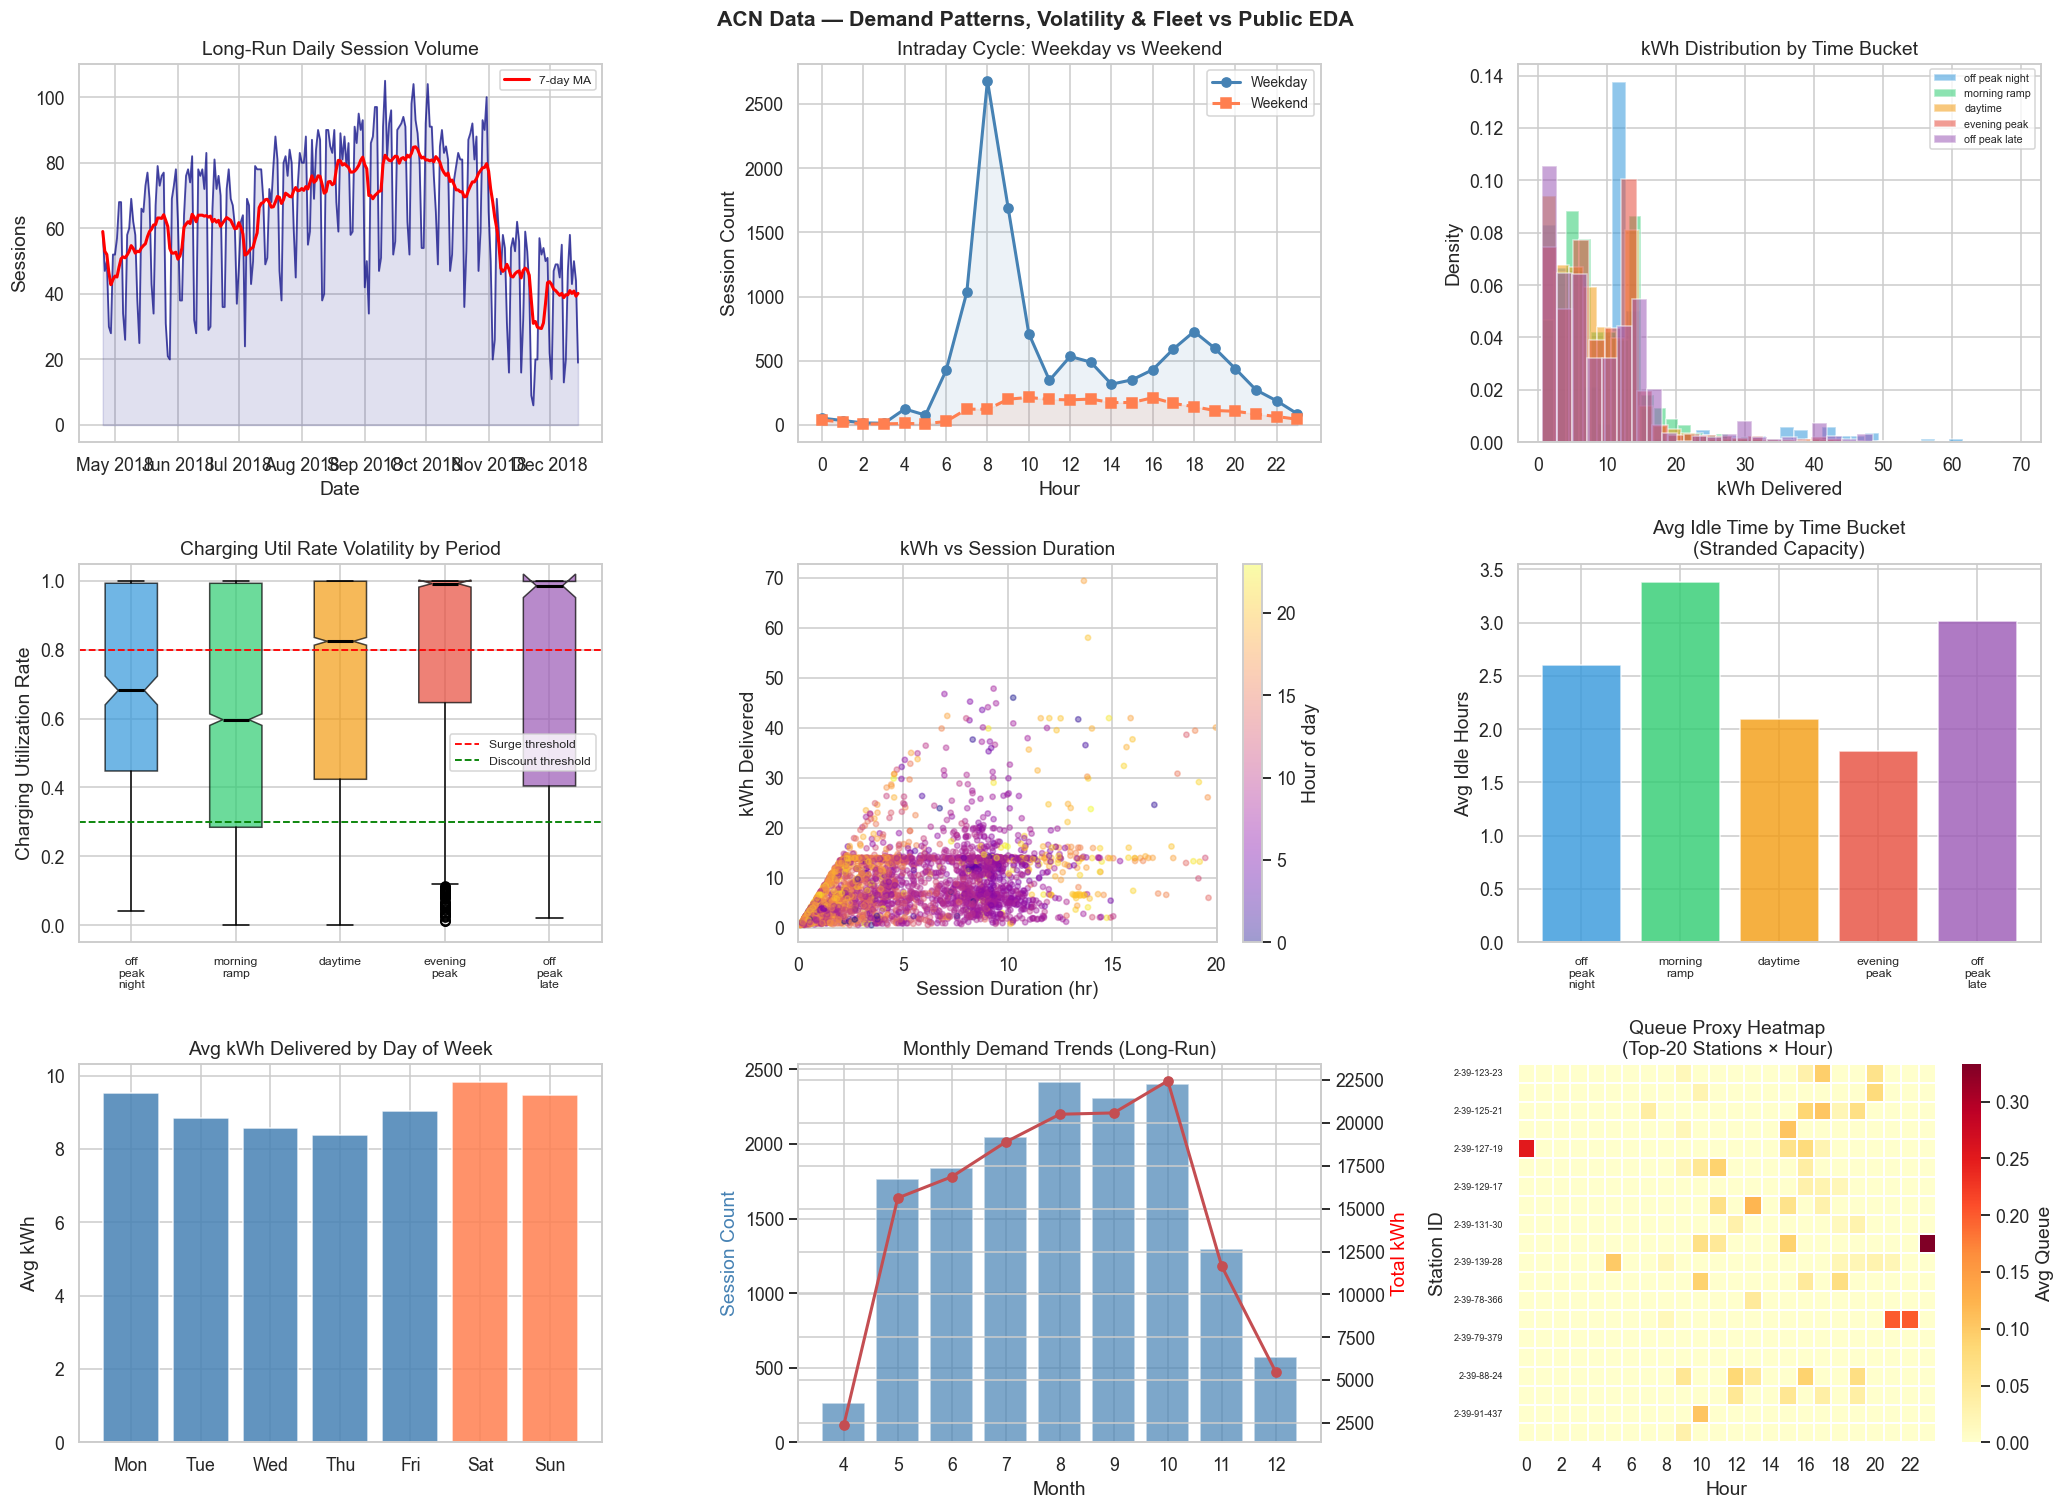

ACN EDA saved.


In [8]:
fig, axes = plt.subplots(3, 3, figsize=(19, 14))
fig.suptitle('ACN Data — Demand Patterns, Volatility & Fleet vs Public EDA', fontsize=14, fontweight='bold')
bucket_colors = ['#3498db','#2ecc71','#f39c12','#e74c3c','#9b59b6']

# 1. Long-run daily sessions trend
ax = axes[0,0]
daily = acn.groupby('date').size().reset_index(name='sessions')
daily['date'] = pd.to_datetime(daily['date'])
ax.plot(daily['date'], daily['sessions'], color='navy', lw=1.2, alpha=0.7)
ax.fill_between(daily['date'], daily['sessions'], alpha=0.12, color='navy')
roll = daily['sessions'].rolling(7, min_periods=1).mean()
ax.plot(daily['date'], roll, color='red', lw=2, label='7-day MA')
ax.set_title('Long-Run Daily Session Volume')
ax.set_xlabel('Date'); ax.set_ylabel('Sessions')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 2. Intraday cycle: sessions by hour (weekday vs weekend)
ax = axes[0,1]
hc = acn.groupby(['hour','is_weekend']).size().unstack(fill_value=0)
hc.columns = ['Weekday','Weekend']
ax.plot(hc.index, hc['Weekday'],  'o-', color='steelblue', lw=2, label='Weekday')
ax.plot(hc.index, hc['Weekend'],  's--',color='coral',     lw=2, label='Weekend')
ax.fill_between(hc.index, hc['Weekday'], alpha=0.1, color='steelblue')
ax.fill_between(hc.index, hc['Weekend'], alpha=0.1, color='coral')
ax.set_title('Intraday Cycle: Weekday vs Weekend')
ax.set_xlabel('Hour'); ax.set_ylabel('Session Count')
ax.legend(fontsize=9); ax.set_xticks(range(0,24,2))

# 3. kWh distribution by time bucket
ax = axes[0,2]
for i,(bkt,clr) in enumerate(zip(bucket_order, bucket_colors)):
    vals = acn.loc[acn['time_bucket']==bkt,'kWhDelivered']
    ax.hist(vals, bins=30, alpha=0.55, color=clr, label=bkt.replace('_',' '), density=True)
ax.set_title('kWh Distribution by Time Bucket')
ax.set_xlabel('kWh Delivered'); ax.set_ylabel('Density')
ax.legend(fontsize=7)

# 4. Charging utilization rate by time bucket (peak vs off-peak volatility)
ax = axes[1,0]
util_by_bucket = [acn.loc[acn['time_bucket']==b,'charging_util_rate'].values for b in bucket_order]
bp = ax.boxplot(util_by_bucket, patch_artist=True, notch=True,
                medianprops=dict(color='black', lw=2))
for patch, clr in zip(bp['boxes'], bucket_colors):
    patch.set_facecolor(clr); patch.set_alpha(0.7)
ax.set_xticks(range(1,6))
ax.set_xticklabels([b.replace('_','\n') for b in bucket_order], fontsize=8)
ax.axhline(0.80, color='red',   lw=1.2, ls='--', label='Surge threshold')
ax.axhline(0.30, color='green', lw=1.2, ls='--', label='Discount threshold')
ax.set_title('Charging Util Rate Volatility by Period')
ax.set_ylabel('Charging Utilization Rate')
ax.legend(fontsize=8)

# 5. kWh vs session duration (scatter, coloured by hour)
ax = axes[1,1]
samp = acn.sample(min(3000, len(acn)), random_state=SEED)
sc = ax.scatter(samp['session_hr'], samp['kWhDelivered'],
                c=samp['hour'], cmap='plasma', alpha=0.4, s=12)
plt.colorbar(sc, ax=ax, label='Hour of day')
ax.set_title('kWh vs Session Duration')
ax.set_xlabel('Session Duration (hr)'); ax.set_ylabel('kWh Delivered')
ax.set_xlim(0, 20)

# 6. Idle hours by time bucket (stranded capacity waste)
ax = axes[1,2]
idle_means = acn.groupby('time_bucket')['idle_hr'].mean().reindex(bucket_order)
ax.bar(range(5), idle_means.values, color=bucket_colors, alpha=0.8)
ax.set_xticks(range(5))
ax.set_xticklabels([b.replace('_','\n') for b in bucket_order], fontsize=8)
ax.set_title('Avg Idle Time by Time Bucket\n(Stranded Capacity)')
ax.set_ylabel('Avg Idle Hours')

# 7. Weekly pattern: avg kWh by day-of-week
ax = axes[2,0]
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_kwh = acn.groupby('dayofweek')['kWhDelivered'].mean()
ax.bar(range(7), dow_kwh.values, color=['steelblue']*5 + ['coral']*2, alpha=0.85)
ax.set_xticks(range(7)); ax.set_xticklabels(days)
ax.set_title('Avg kWh Delivered by Day of Week')
ax.set_ylabel('Avg kWh')

# 8. Monthly trend (long-run demand growth)
ax = axes[2,1]
monthly = acn.groupby('month').agg(sessions=('sessionID','count'),
                                    kwh=('kWhDelivered','sum')).reset_index()
ax2_r = ax.twinx()
ax.bar(monthly['month'], monthly['sessions'], color='steelblue', alpha=0.7, label='Sessions')
ax2_r.plot(monthly['month'], monthly['kwh'], 'ro-', lw=2, label='Total kWh')
ax.set_title('Monthly Demand Trends (Long-Run)')
ax.set_xlabel('Month'); ax.set_ylabel('Session Count', color='steelblue')
ax2_r.set_ylabel('Total kWh', color='red')
ax.set_xticks(monthly['month'])

# 9. Queue proxy heatmap by station × hour
ax = axes[2,2]
queue_heat = acn_hourly.groupby(['stationID','hour'])['queue_proxy'].mean().unstack(fill_value=0)
# Take top-20 busiest stations
top_stations = acn_hourly.groupby('stationID')['sessions_in_slot'].sum().nlargest(20).index
queue_heat_top = queue_heat.loc[queue_heat.index.isin(top_stations)]
sns.heatmap(queue_heat_top, ax=ax, cmap='YlOrRd', linewidths=0.2, cbar_kws={'label':'Avg Queue'})
ax.set_title('Queue Proxy Heatmap\n(Top-20 Stations × Hour)')
ax.set_xlabel('Hour'); ax.set_ylabel('Station ID')
ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.savefig('eda_acn_full.png')
plt.show()
print('ACN EDA saved.')

### 4B. Urban (ST-EVCDP) — Temporal Patterns, Spatial Heterogeneity, Peak Volatility

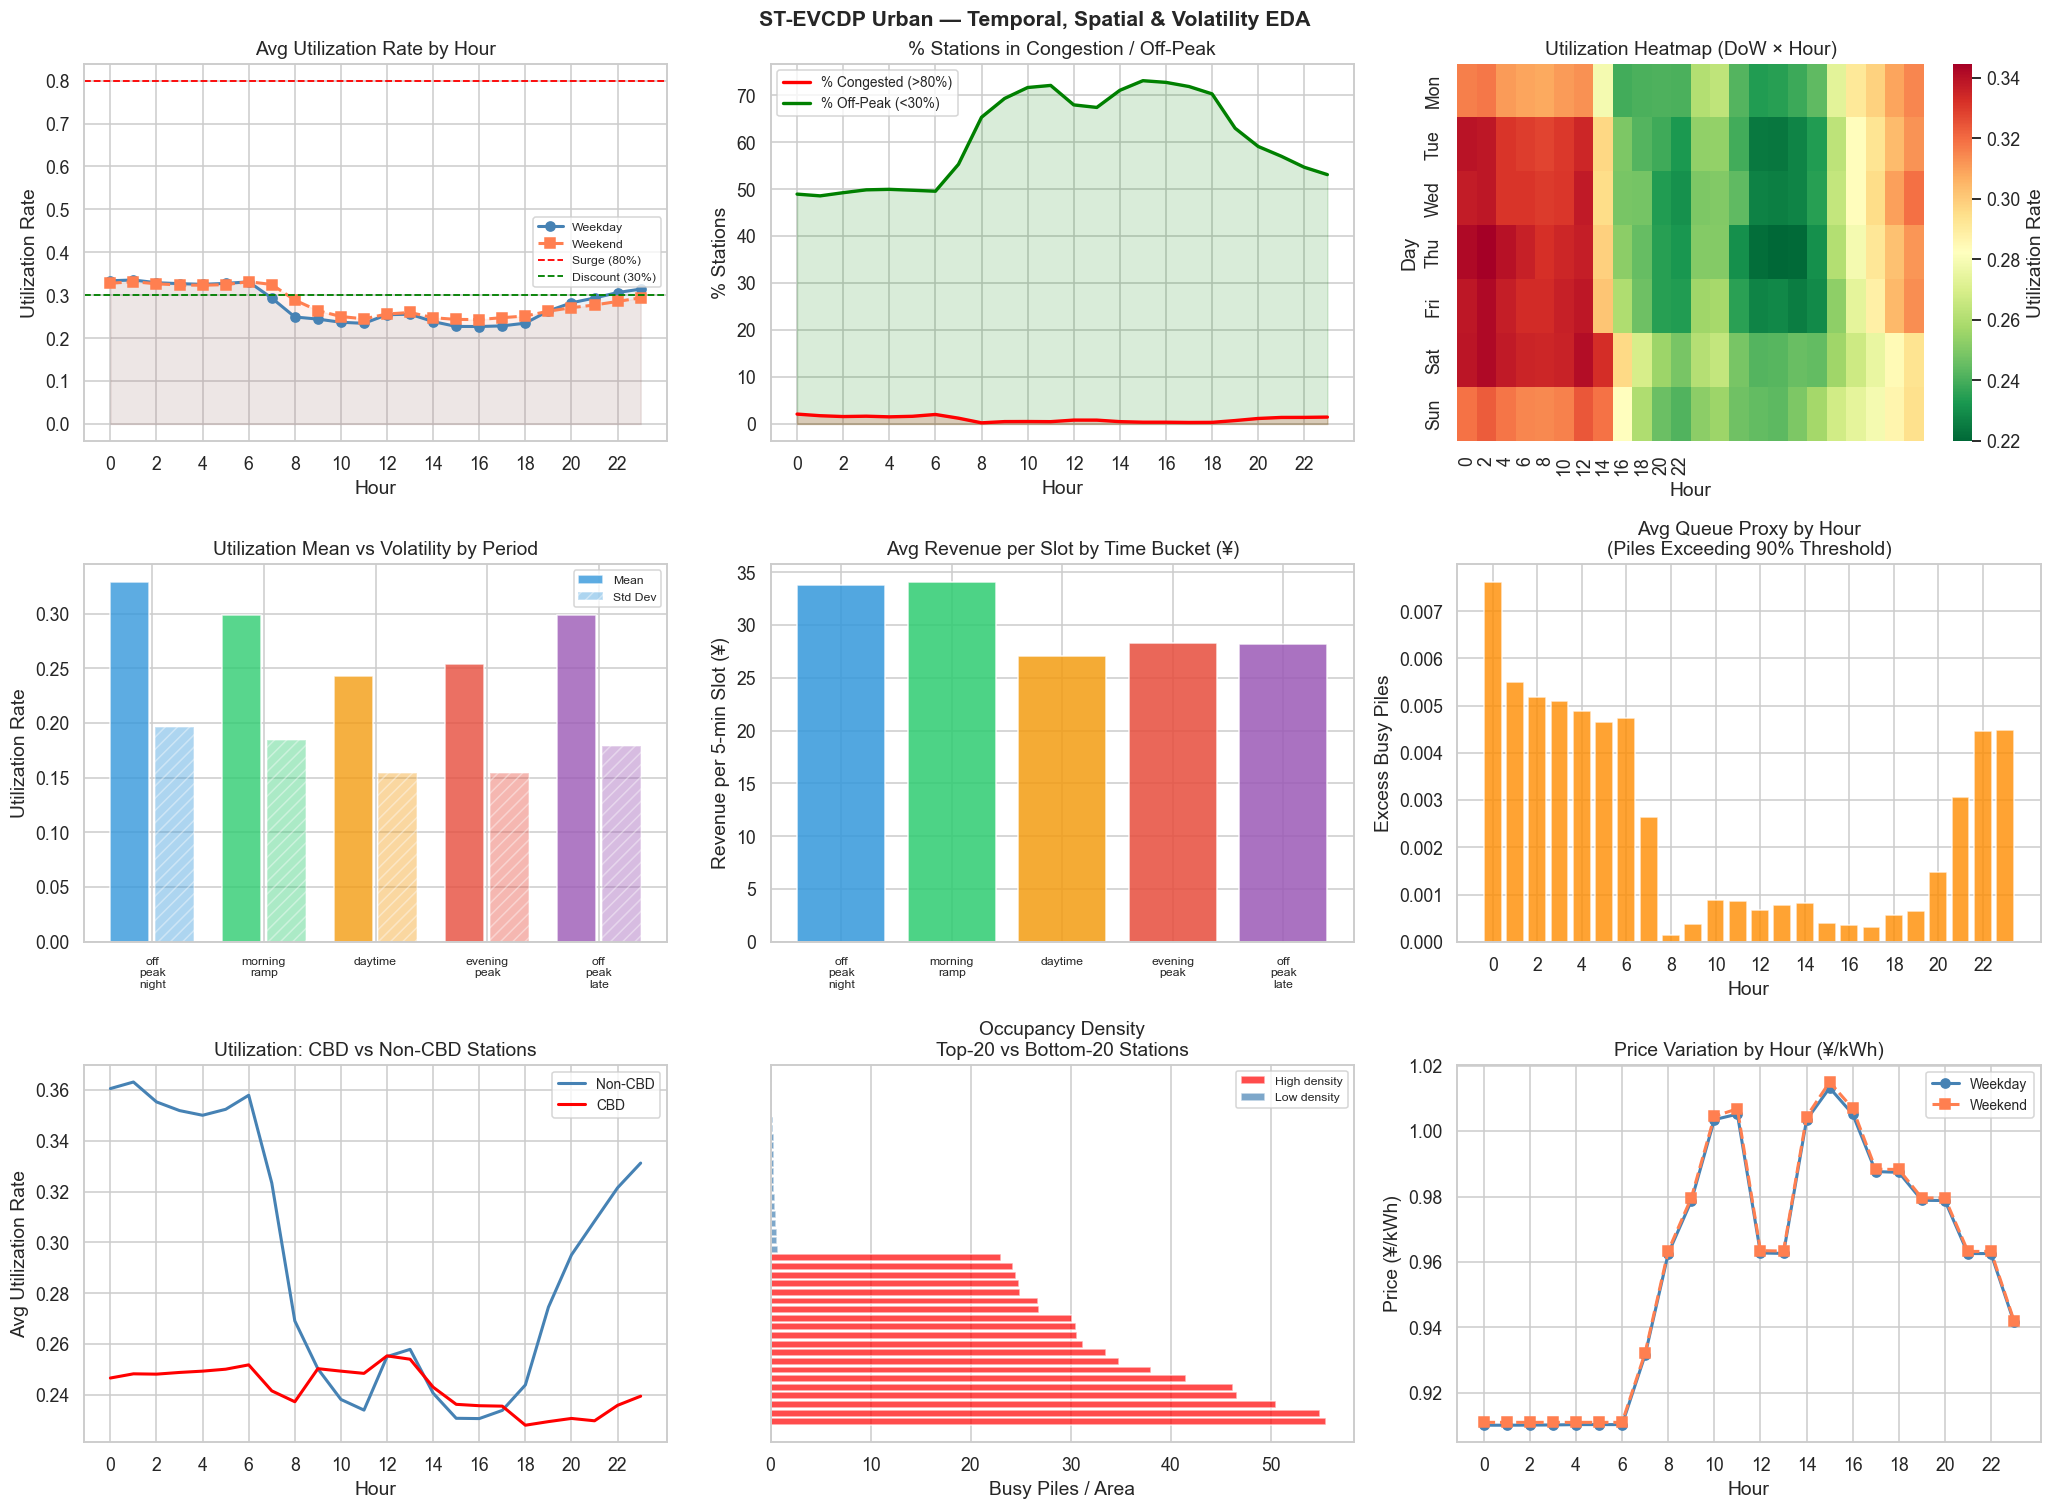

Urban EDA saved.


In [9]:
fig, axes = plt.subplots(3, 3, figsize=(19, 14))
fig.suptitle('ST-EVCDP Urban — Temporal, Spatial & Volatility EDA', fontsize=14, fontweight='bold')

# 1. Avg utilization by hour (weekday vs weekend)
ax = axes[0,0]
hu = urban.groupby(['hour','is_weekend'])['util_rate'].mean().unstack(fill_value=0)
hu.columns = ['Weekday','Weekend']
ax.plot(hu.index, hu['Weekday'],  'o-', color='steelblue', lw=2, label='Weekday')
ax.plot(hu.index, hu['Weekend'],  's--',color='coral',     lw=2, label='Weekend')
ax.fill_between(hu.index, hu['Weekday'], alpha=0.1, color='steelblue')
ax.fill_between(hu.index, hu['Weekend'], alpha=0.1, color='coral')
ax.axhline(0.80, color='red',   ls='--', lw=1.2, label='Surge (80%)')
ax.axhline(0.30, color='green', ls='--', lw=1.2, label='Discount (30%)')
ax.set_title('Avg Utilization Rate by Hour')
ax.set_xlabel('Hour'); ax.set_ylabel('Utilization Rate')
ax.legend(fontsize=8); ax.set_xticks(range(0,24,2))

# 2. Congestion & off-peak hours by hour of day
ax = axes[0,1]
cong = urban.groupby('hour')['is_congested'].mean()*100
offpk= urban.groupby('hour')['is_off_peak'].mean()*100
ax.plot(cong.index,  cong.values,  color='red',   lw=2.2, label='% Congested (>80%)')
ax.plot(offpk.index, offpk.values, color='green', lw=2.2, label='% Off-Peak (<30%)')
ax.fill_between(cong.index, cong.values, alpha=0.15, color='red')
ax.fill_between(offpk.index,offpk.values,alpha=0.15, color='green')
ax.set_title('% Stations in Congestion / Off-Peak')
ax.set_xlabel('Hour'); ax.set_ylabel('% Stations')
ax.legend(fontsize=9); ax.set_xticks(range(0,24,2))

# 3. DoW × Hour heatmap
ax = axes[0,2]
pivot = urban.groupby(['dayofweek','hour'])['util_rate'].mean().unstack()
sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', linewidths=0,
            xticklabels=range(0,24,2),
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
            cbar_kws={'label':'Utilization Rate'})
ax.set_title('Utilization Heatmap (DoW × Hour)')
ax.set_xlabel('Hour'); ax.set_ylabel('Day')

# 4. Volatility by time bucket (std of utilization)
ax = axes[1,0]
vol_by_bkt = urban.groupby('time_bucket')['util_rate'].std().reindex(bucket_order)
mean_by_bkt= urban.groupby('time_bucket')['util_rate'].mean().reindex(bucket_order)
x = np.arange(5)
ax.bar(x-0.2, mean_by_bkt.values, 0.35, color=bucket_colors, alpha=0.8, label='Mean')
ax.bar(x+0.2, vol_by_bkt.values,  0.35, color=bucket_colors, alpha=0.4, label='Std Dev', hatch='///')
ax.set_xticks(x)
ax.set_xticklabels([b.replace('_','\n') for b in bucket_order], fontsize=8)
ax.set_title('Utilization Mean vs Volatility by Period')
ax.set_ylabel('Utilization Rate'); ax.legend(fontsize=8)

# 5. Revenue by time bucket
ax = axes[1,1]
rev_bkt = urban.groupby('time_bucket')['revenue_per_slot'].mean().reindex(bucket_order)
ax.bar(range(5), rev_bkt.values, color=bucket_colors, alpha=0.85)
ax.set_xticks(range(5))
ax.set_xticklabels([b.replace('_','\n') for b in bucket_order], fontsize=8)
ax.set_title('Avg Revenue per Slot by Time Bucket (¥)')
ax.set_ylabel('Revenue per 5-min Slot (¥)')

# 6. Queue proxy across hours
ax = axes[1,2]
q_by_hour = urban.groupby('hour')['queue_proxy'].mean()
ax.bar(q_by_hour.index, q_by_hour.values, color='darkorange', alpha=0.8)
ax.set_title('Avg Queue Proxy by Hour\n(Piles Exceeding 90% Threshold)')
ax.set_xlabel('Hour'); ax.set_ylabel('Excess Busy Piles')
ax.set_xticks(range(0,24,2))

# 7. CBD vs non-CBD utilization profile
ax = axes[2,0]
cbd_hu = urban.groupby(['hour','CBD'])['util_rate'].mean().unstack(fill_value=0)
cbd_hu.columns = ['Non-CBD','CBD'] if 0 in cbd_hu.columns else cbd_hu.columns
for col, clr, lbl in zip(cbd_hu.columns, ['steelblue','red'], ['Non-CBD','CBD']):
    ax.plot(cbd_hu.index, cbd_hu[col], lw=2, label=lbl, color=clr)
ax.set_title('Utilization: CBD vs Non-CBD Stations')
ax.set_xlabel('Hour'); ax.set_ylabel('Avg Utilization Rate')
ax.legend(fontsize=9); ax.set_xticks(range(0,24,2))

# 8. Occupancy density by station cluster (top/bottom 20)
ax = axes[2,1]
occ_dens_s = urban.groupby('station_id')['occupancy_density'].mean().sort_values()
top20  = occ_dens_s.tail(20)
bot20  = occ_dens_s.head(20)
ax.barh(range(20), top20.values[::-1],  color='red',       alpha=0.7, label='High density')
ax.barh(range(20,40), bot20.values[::-1], color='steelblue', alpha=0.7, label='Low density')
ax.set_title('Occupancy Density\nTop-20 vs Bottom-20 Stations')
ax.set_xlabel('Busy Piles / Area'); ax.legend(fontsize=8)
ax.set_yticks([])

# 9. Price variation across hours
ax = axes[2,2]
price_hour = urban.groupby(['hour','is_weekend'])['price_yuan_kwh'].mean().unstack(fill_value=0)
price_hour.columns = ['Weekday','Weekend']
ax.plot(price_hour.index, price_hour['Weekday'],  'o-', color='steelblue', lw=2, label='Weekday')
ax.plot(price_hour.index, price_hour['Weekend'],  's--',color='coral',     lw=2, label='Weekend')
ax.set_title('Price Variation by Hour (¥/kWh)')
ax.set_xlabel('Hour'); ax.set_ylabel('Price (¥/kWh)')
ax.legend(fontsize=9); ax.set_xticks(range(0,24,2))

plt.tight_layout()
plt.savefig('eda_urban_full.png')
plt.show()
print('Urban EDA saved.')

---
## 5. Station Efficiency Index (Optimization Model)

We derive a per-station **Efficiency Index** $E_s \in [0,1]$ by solving a resource allocation problem. A station is efficient if it maximizes revenue while minimizing congestion and idle waste.

### Mathematical Framework

Define the station efficiency score as a weighted composite:

$$E_s = w_1 \cdot \bar{u}_s^* + w_2 \cdot \tilde{\pi}_s - w_3 \cdot \sigma_s - w_4 \cdot q_s$$

where:
- $\bar{u}_s^*$ = normalized mean utilization (target: $u^* \in [0.5, 0.8]$, penalized outside)
- $\tilde{\pi}_s$ = normalized revenue per kWh
- $\sigma_s$ = normalized utilization volatility (instability cost)
- $q_s$ = normalized queue proxy (congestion externality)

Weights $(w_1, w_2, w_3, w_4)$ are estimated by solving:
$$\max_{w} \sum_s E_s \quad \text{s.t.} \quad \sum_i w_i = 1,\; w_i \geq 0$$

with the constraint that $E_s$ correlates with $\text{Revenue}/\text{kWh}$ while penalizing congestion.

In [10]:
# ── Station-level summary features ──────────────────────────────────────────
station_stats = urban.groupby('station_id').agg(
    mean_util   =('util_rate',       'mean'),
    vol_util    =('util_rate',       'std'),
    mean_kwh    =('kwh_per_slot',    'mean'),
    mean_rev    =('revenue_per_slot','mean'),
    mean_price  =('price_yuan_kwh',  'mean'),
    mean_queue  =('queue_proxy',     'mean'),
    mean_occ_den=('occupancy_density','mean'),
    pct_cong    =('is_congested',    'mean'),
    pct_offpk   =('is_off_peak',     'mean'),
    total_kwh   =('kwh_per_slot',    'sum'),
    count       =('count',           'first'),
    fast_ratio  =('fast_ratio',      'first'),
    CBD         =('CBD',             'first')
).dropna().reset_index()

# Normalize each metric to [0,1]
def norm01(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

# Utilization score: highest when util is in optimal band [0.5, 0.8]
def util_optimality(u):
    """Triangular score: 1 at u=0.65, 0 at u=0 or u=1."""
    return 1 - np.abs(u - 0.65) / 0.65

station_stats['util_opt']  = util_optimality(station_stats['mean_util'])
station_stats['rev_norm']  = norm01(station_stats['mean_price'])         # higher price = better
station_stats['vol_norm']  = 1 - norm01(station_stats['vol_util'])       # lower volatility = better
station_stats['queue_norm']= 1 - norm01(station_stats['mean_queue'])     # lower queue = better

# Optimization: find weights that maximize total E while correlating with revenue
from scipy.optimize import minimize, LinearConstraint

X_eff = station_stats[['util_opt','rev_norm','vol_norm','queue_norm']].values
y_rev = station_stats['mean_price'].values

def neg_corr_with_constraint(w):
    E = X_eff @ w
    return -np.corrcoef(E, y_rev)[0,1]   # maximize correlation with revenue

w0 = np.array([0.25, 0.25, 0.25, 0.25])
constraints = [{'type':'eq',  'fun': lambda w: w.sum() - 1},
               {'type':'ineq','fun': lambda w: w}]          # w_i >= 0

result = minimize(neg_corr_with_constraint, w0,
                  method='SLSQP', constraints=constraints,
                  options={'ftol':1e-9,'maxiter':500})

w_opt = result.x.clip(0)
w_opt = w_opt / w_opt.sum()   # re-normalize

print(f'Optimal weights: util_opt={w_opt[0]:.3f}, rev={w_opt[1]:.3f}, '
      f'vol={w_opt[2]:.3f}, queue={w_opt[3]:.3f}')
print(f'Optimization success: {result.success}')

# Compute efficiency index
station_stats['efficiency_index'] = X_eff @ w_opt
station_stats['efficiency_index'] = norm01(station_stats['efficiency_index'])  # scale to [0,1]

# Efficiency tier
station_stats['eff_tier'] = pd.cut(
    station_stats['efficiency_index'],
    bins=[0, 0.33, 0.66, 1.01],
    labels=['Low','Medium','High']
)

print('\nEfficiency Index distribution:')
print(station_stats['efficiency_index'].describe().round(3))
print(station_stats['eff_tier'].value_counts())

# Save for merging into model features
eff_map = station_stats.set_index('station_id')['efficiency_index'].to_dict()
urban['efficiency_index'] = urban['station_id'].map(eff_map).fillna(0.5)

station_stats.to_csv('station_efficiency_index.csv', index=False)
print('\nStation efficiency index saved.')

Optimal weights: util_opt=0.000, rev=1.000, vol=0.000, queue=0.000
Optimization success: True

Efficiency Index distribution:
count    247.000
mean       0.515
std        0.192
min        0.000
25%        0.371
50%        0.536
75%        0.634
max        1.000
Name: efficiency_index, dtype: float64
eff_tier
Medium    144
Low        53
High       49
Name: count, dtype: int64

Station efficiency index saved.


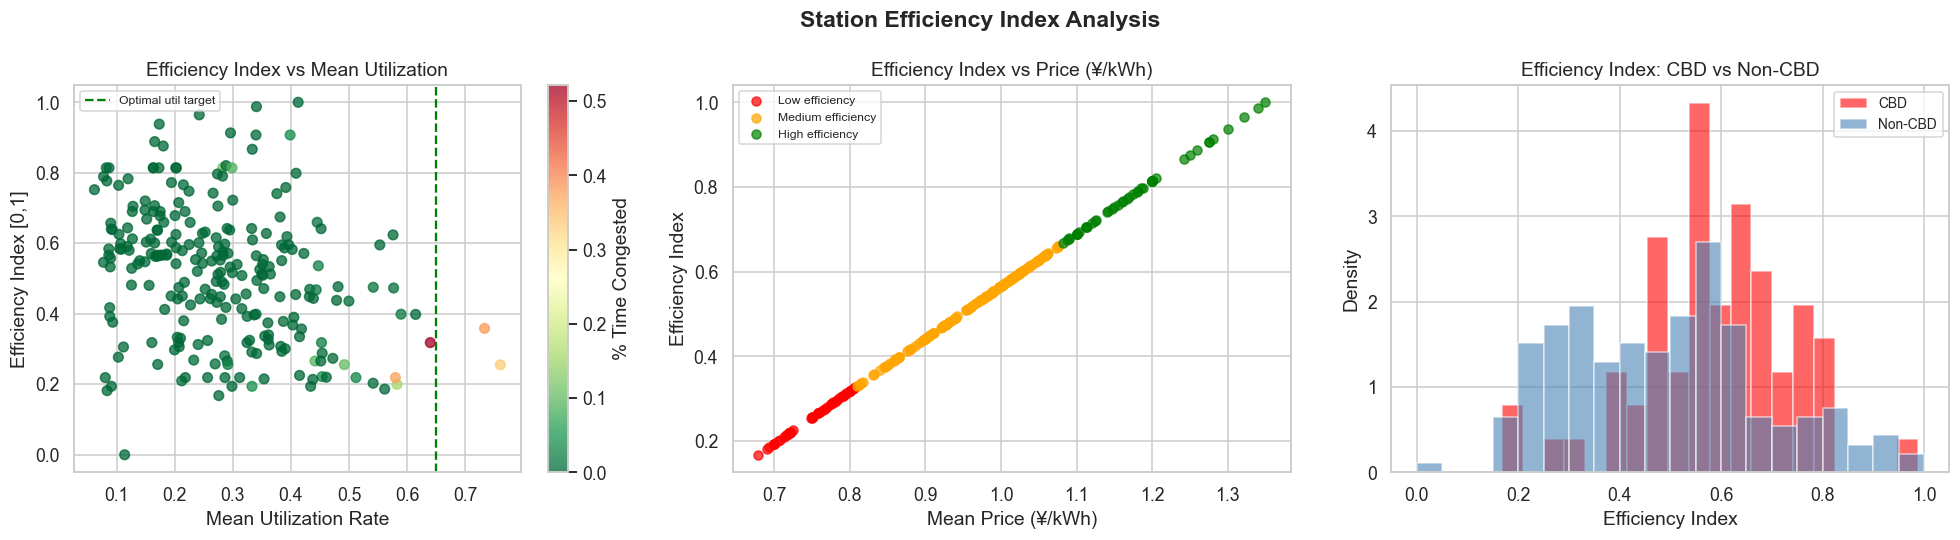

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Station Efficiency Index Analysis', fontweight='bold')

# Efficiency vs utilization
ax = axes[0]
sc = ax.scatter(station_stats['mean_util'], station_stats['efficiency_index'],
                c=station_stats['pct_cong'], cmap='RdYlGn_r', s=40, alpha=0.75)
plt.colorbar(sc, ax=ax, label='% Time Congested')
ax.set_title('Efficiency Index vs Mean Utilization')
ax.set_xlabel('Mean Utilization Rate'); ax.set_ylabel('Efficiency Index [0,1]')
ax.axvline(0.65, ls='--', color='green', lw=1.5, label='Optimal util target')
ax.legend(fontsize=8)

# Efficiency vs revenue
ax = axes[1]
for tier, clr in [('Low','red'),('Medium','orange'),('High','green')]:
    mask = station_stats['eff_tier'] == tier
    ax.scatter(station_stats.loc[mask,'mean_price'],
               station_stats.loc[mask,'efficiency_index'],
               label=f'{tier} efficiency', color=clr, alpha=0.7, s=35)
ax.set_title('Efficiency Index vs Price (¥/kWh)')
ax.set_xlabel('Mean Price (¥/kWh)'); ax.set_ylabel('Efficiency Index')
ax.legend(fontsize=8)

# Distribution of efficiency across CBD/non-CBD
ax = axes[2]
for cbd_val, lbl, clr in [(1,'CBD','red'),(0,'Non-CBD','steelblue')]:
    vals = station_stats.loc[station_stats['CBD']==cbd_val, 'efficiency_index']
    ax.hist(vals, bins=20, alpha=0.6, color=clr, label=lbl, density=True)
ax.set_title('Efficiency Index: CBD vs Non-CBD')
ax.set_xlabel('Efficiency Index'); ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('efficiency_index_analysis.png')
plt.show()

---
## 6. Temporal-Network Demand Model

### Mathematical Framework

#### 6.1 Demand Function

The demand for charging at station $s$ in slot $t$ is:

$$D_{s,t} = \alpha_s + \beta_1 \tau_{s,t} + \beta_2 u_{s,t-1} + \beta_3 \bar{D}_{\mathcal{N}(s),t-1} + \gamma X_{s,t} + \varepsilon_{s,t}$$

where:
- $\tau_{s,t}$ = tariff (price) at station $s$, slot $t$ — own-price effect
- $u_{s,t-1}$ = lagged utilization — persistence / habit formation
- $\bar{D}_{\mathcal{N}(s),t-1}$ = **demand spillover**: weighted average of adjacent stations' lagged demand (network effect)
- $X_{s,t}$ = temporal and station covariates
- $\alpha_s$ = station fixed effect

#### 6.2 Network Spillover

The spillover term captures how congestion at neighboring stations redirects demand:

$$\text{Spillover}_{s,t} = \sum_{j \in \mathcal{N}(s)} W_{sj} \cdot u_{j,t-1}, \quad W_{sj} = \frac{A_{sj}}{d_{sj}^\delta}$$

where $A_{sj} \in \{0,1\}$ is the adjacency, $d_{sj}$ is distance (km), and $\delta$ is a distance decay parameter (estimated).

#### 6.3 Tariff Premium Decomposition

The optimal tariff is decomposed into additive premiums:

$$\tau^*_{s,t} = \underbrace{\tau_0}_{\text{base}} + \underbrace{\pi^{\text{cong}}_{s,t}}_{\text{congestion}} + \underbrace{\pi^{\text{spill}}_{s,t}}_{\text{spillover}} + \underbrace{\pi^{\text{eff}}_{s}}_{\text{efficiency}} + \underbrace{\pi^{\text{time}}_{t}}_{\text{time-of-day}} + \underbrace{\pi^{\text{fast}}_{s}}_{\text{fast-charger}}$$

Each premium is derived from the demand model estimates:
- **Congestion premium**: $\pi^{\text{cong}} = \theta_1 \cdot \max(u_{s,t} - 0.8, 0)$
- **Spillover premium**: $\pi^{\text{spill}} = \theta_2 \cdot \text{Spillover}_{s,t}$
- **Efficiency premium**: $\pi^{\text{eff}} = \theta_3 \cdot E_s$ (reward high-efficiency stations with higher tariff capture)
- **Time-of-day premium**: $\pi^{\text{time}} = \theta_4 \cdot \mathbb{1}[\text{peak}]$
- **Fast-charger premium**: $\pi^{\text{fast}} = \theta_5 \cdot f_s$ (fast-charger ratio)

In [12]:
# ── Build Spatial Weights Matrix ─────────────────────────────────────────────
adj_mat  = adj_df.set_index('node_id')
adj_mat.columns = adj_mat.columns.astype(str)
adj_mat.index   = adj_mat.index.astype(str)

dist_mat = distance_df.set_index('Unnamed: 0')
dist_mat.columns = dist_mat.columns.astype(str)
dist_mat.index   = dist_mat.index.astype(str)

# Stations present in both
common_stations = list(set(adj_mat.index) & set(dist_mat.index))
common_stations.sort()
adj_sq   = adj_mat.loc[common_stations, common_stations].values.astype(float)
dist_sq  = dist_mat.loc[common_stations, common_stations].values.astype(float)

# Spatial weight: W_sj = A_sj / (d_sj + 1)^delta
DELTA = 1.5   # distance decay
with np.errstate(divide='ignore', invalid='ignore'):
    W_raw = adj_sq / np.where(dist_sq > 0, (dist_sq + 0.01)**DELTA, 1e-6)
    W_raw[adj_sq == 0] = 0

# Row-normalize
row_sums = W_raw.sum(axis=1, keepdims=True)
W = np.where(row_sums > 0, W_raw / row_sums, 0)

print(f'Spatial weight matrix: {W.shape}')
print(f'Avg non-zero neighbors: {(W>0).sum(axis=1).mean():.1f}')

Spatial weight matrix: (24, 24)
Avg non-zero neighbors: 3.6


In [13]:
# ── Compute Network Spillover Feature ────────────────────────────────────────
# For each timestamp, util vector U_t shape (N,)
# Spillover_t = W @ U_t  (weighted avg neighbors' lagged util)

# Pivot utilization to wide (T × N)
urban_sorted = urban.sort_values(['datetime','station_id'])

# Only keep stations in the spatial weight matrix
urban_net = urban_sorted[urban_sorted['station_id'].isin(common_stations)].copy()
print(f'Stations in network model: {urban_net.station_id.nunique()}')

# Pivot to wide
util_wide = urban_net.pivot_table(index='datetime', columns='station_id',
                                   values='util_rate', aggfunc='mean')
util_wide = util_wide[common_stations]   # ensure column order matches W
util_wide_vals = util_wide.values        # (T, N)

# Lagged utilization (1 step)
util_lag1 = np.roll(util_wide_vals, 1, axis=0)
util_lag1[0] = util_wide_vals[0]         # no lag for first row

# Spillover: W @ util_lag1.T  → shape (N, T), then transpose
spillover = (W @ util_lag1.T).T          # shape (T, N)

# Unstack back to long format
spillover_df = pd.DataFrame(
    spillover, index=util_wide.index, columns=common_stations
).stack().reset_index()
spillover_df.columns = ['datetime','station_id','spillover_util']
spillover_df['station_id'] = spillover_df['station_id'].astype(str)

# Merge back into urban
urban_net = urban_net.merge(spillover_df, on=['datetime','station_id'], how='left')
urban_net['spillover_util'] = urban_net['spillover_util'].fillna(0)

print(f'Spillover feature stats:')
print(urban_net['spillover_util'].describe().round(3))

Stations in network model: 24
Spillover feature stats:
count    207360.000
mean          0.228
std           0.120
min           0.000
25%           0.156
50%           0.203
75%           0.257
max           0.800
Name: spillover_util, dtype: float64


In [14]:
# ── Build Final Modelling Dataset (multi-feature, not single-predictor) ──────
FEATURES = [
    # Temporal cyclic
    'hour_sin','hour_cos','dow_sin','dow_cos','slot_sin','slot_cos','is_weekend',
    # Lag features — utilization and kWh
    'util_lag1','util_lag12','util_lag288',
    'kwh_lag1','kwh_lag12','kwh_lag288',
    # Rolling means
    'util_roll12','util_roll288','kwh_roll12',
    # Volatility
    'util_vol12',
    # Network spillover
    'spillover_util',
    # Station structural
    'count','fast_ratio','CBD','efficiency_index',
    # Price
    'price_yuan_kwh','energy_cost_kwh',
]
TARGET = 'util_rate'

# Ensure lag columns exist in urban_net
urban_net['util_lag1']   = urban_net.groupby('station_id')['util_rate'].shift(1)
urban_net['util_lag12']  = urban_net.groupby('station_id')['util_rate'].shift(12)
urban_net['util_lag288'] = urban_net.groupby('station_id')['util_rate'].shift(288)
urban_net['kwh_lag1']    = urban_net.groupby('station_id')['kwh_per_slot'].shift(1)
urban_net['kwh_lag12']   = urban_net.groupby('station_id')['kwh_per_slot'].shift(12)
urban_net['kwh_lag288']  = urban_net.groupby('station_id')['kwh_per_slot'].shift(288)
urban_net['util_roll12'] = urban_net.groupby('station_id')['util_rate'].transform(
    lambda x: x.rolling(12, min_periods=1).mean())
urban_net['util_roll288']= urban_net.groupby('station_id')['util_rate'].transform(
    lambda x: x.rolling(288, min_periods=1).mean())
urban_net['kwh_roll12']  = urban_net.groupby('station_id')['kwh_per_slot'].transform(
    lambda x: x.rolling(12, min_periods=1).mean())
urban_net['util_vol12']  = urban_net.groupby('station_id')['util_rate'].transform(
    lambda x: x.rolling(12, min_periods=2).std().fillna(0))

# efficiency_index already merged earlier
if 'efficiency_index' not in urban_net.columns:
    urban_net['efficiency_index'] = urban_net['station_id'].map(eff_map).fillna(0.5)

model_df = urban_net[FEATURES + [TARGET, 'datetime', 'station_id',
                                  'kwh_per_slot', 'avg_duration_hr',
                                  'busy_piles', 'price_yuan_kwh',
                                  'revenue_per_slot', 'is_congested',
                                  'is_off_peak', 'time_bucket', 'hour',
                                  'queue_proxy', 'occupancy_density']].dropna()

model_df = model_df.sort_values('datetime').reset_index(drop=True)
print(f'Modelling dataset: {model_df.shape}')
print(f'Features: {len(FEATURES)}')
print(f'Target mean: {model_df[TARGET].mean():.3f}, std: {model_df[TARGET].std():.3f}')

Modelling dataset: (200448, 38)
Features: 24
Target mean: 0.224, std: 0.144


---
## 7. Demand Prediction Agent

Multi-feature time-series model. Time-respecting train/test split (80/20 chronological).

In [15]:
# ── Train/Test Split (chronological) ────────────────────────────────────────
split_idx = int(len(model_df) * 0.80)
train_df  = model_df.iloc[:split_idx].copy()
test_df   = model_df.iloc[split_idx:].copy()

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Test contains: kwh_per_slot={"kwh_per_slot" in test_df.columns}, '
      f'revenue_per_slot={"revenue_per_slot" in test_df.columns}')

Train: (160358, 25)  |  Test: (40090, 25)
Test contains: kwh_per_slot=True, revenue_per_slot=True


In [ ]:
# ── Demand Prediction Agent: Gradient Boosting ───────────────────────────────
gb = GradientBoostingRegressor(
    n_estimators=400, learning_rate=0.04,
    max_depth=5, subsample=0.75,
    min_samples_leaf=30, random_state=SEED
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test).clip(0, 1)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print('=== Demand Prediction Agent — Gradient Boosting ===')
print(f'RMSE : {rmse_gb:.4f}')
print(f'MAE  : {mae_gb:.4f}')
print(f'R²   : {r2_gb:.4f}')

=== Demand Prediction Agent — Gradient Boosting ===
RMSE : 0.0094
MAE  : 0.0036
R²   : 0.9960


In [ ]:
# ── Benchmark: Random Forest ─────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=300, max_depth=12,
    min_samples_leaf=30, n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test).clip(0, 1)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print('=== Benchmark: Random Forest ===')
print(f'RMSE : {rmse_rf:.4f}')
print(f'MAE  : {mae_rf:.4f}')
print(f'R²   : {r2_rf:.4f}')

demand_metrics = pd.DataFrame({
    'model':['GradientBoosting','RandomForest'],
    'RMSE':[rmse_gb,rmse_rf], 'MAE':[mae_gb,mae_rf], 'R2':[r2_gb,r2_rf]
})
demand_metrics.to_csv('demand_prediction_metrics.csv', index=False)

=== Benchmark: Random Forest ===
RMSE : 0.0094
MAE  : 0.0038
R²   : 0.9960


In [20]:
test_df

,hour_sin,hour_cos,dow_sin,dow_cos,slot_sin,slot_cos,is_weekend,util_lag1,util_lag12,util_lag288,...,is_congested,is_off_peak,time_bucket,hour,queue_proxy,occupancy_density,pred_util,pred_congested,pred_off_peak,congestion_prob
160358,0.866025,0.500000,0.974928,-0.222521,0.946930,0.321439,0,0.204301,0.172043,0.150538,...,0,1,off_peak_night,4,0.0,19.000000,0.202169,0,1,0.202169
160359,0.866025,0.500000,0.974928,-0.222521,0.946930,0.321439,0,0.193182,0.193182,0.215909,...,0,1,off_peak_night,4,0.0,17.000000,0.193165,0,1,0.193165
160360,0.866025,0.500000,0.974928,-0.222521,0.946930,0.321439,0,0.487179,0.487179,0.487179,...,0,0,off_peak_night,4,0.0,15.079365,0.486724,0,0,0.486724
160361,0.866025,0.500000,0.974928,-0.222521,0.946930,0.321439,0,0.230769,0.230769,0.128205,...,0,1,off_peak_night,4,0.0,2.857143,0.230608,0,1,0.230608
160362,0.866025,0.500000,0.974928,-0.222521,0.946930,0.321439,0,0.350877,0.350877,0.245614,...,0,0,off_peak_night,4,0.0,9.803922,0.350650,0,0,0.350650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200443,-0.258819,0.965926,0.000000,1.000000,-0.021815,0.999762,0,0.182796,0.150538,0.215054,...,0,1,off_peak_late,23,0.0,14.000000,0.182504,0,1,0.182504
200444,-0.258819,0.965926,0.000000,1.000000,-0.021815,0.999762,0,0.600000,0.600000,0.666667,...,0,0,off_peak_late,23,0.0,16.000000,0.602309,0,0,0.602309
200445,-0.258819,0.965926,0.000000,1.000000,-0.021815,0.999762,0,0.442105,0.431579,0.526316,...,0,0,off_peak_late,23,0.0,25.609756,0.442579,0,0,0.442579
200446,-0.258819,0.965926,0.000000,1.000000,-0.021815,0.999762,0,0.157895,0.175439,0.210526,...,0,1,off_peak_late,23,0.0,4.411765,0.158205,0,1,0.158205


In [ ]:
# ── Attach predictions to test_df ────────────────────────────────────────────
# test_df already contains kwh_per_slot, avg_duration_hr, etc. from model_df
best_model, y_pred = gb, y_pred_gb
test_df = test_df.copy()
test_df['pred_util']       = y_pred
test_df['pred_congested']  = (y_pred >= 0.80).astype(int)
test_df['pred_off_peak']   = (y_pred < 0.30).astype(int)
test_df['congestion_prob'] = y_pred.clip(0, 1)

print('Congestion classification report:')
print(classification_report(
    test_df['is_congested'],
    test_df['pred_congested'],
    #target_names=['Not Congested','Congested'],
    zero_division=0
))

Congestion classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     40090

    accuracy                           1.00     40090
   macro avg       1.00      1.00      1.00     40090
weighted avg       1.00      1.00      1.00     40090



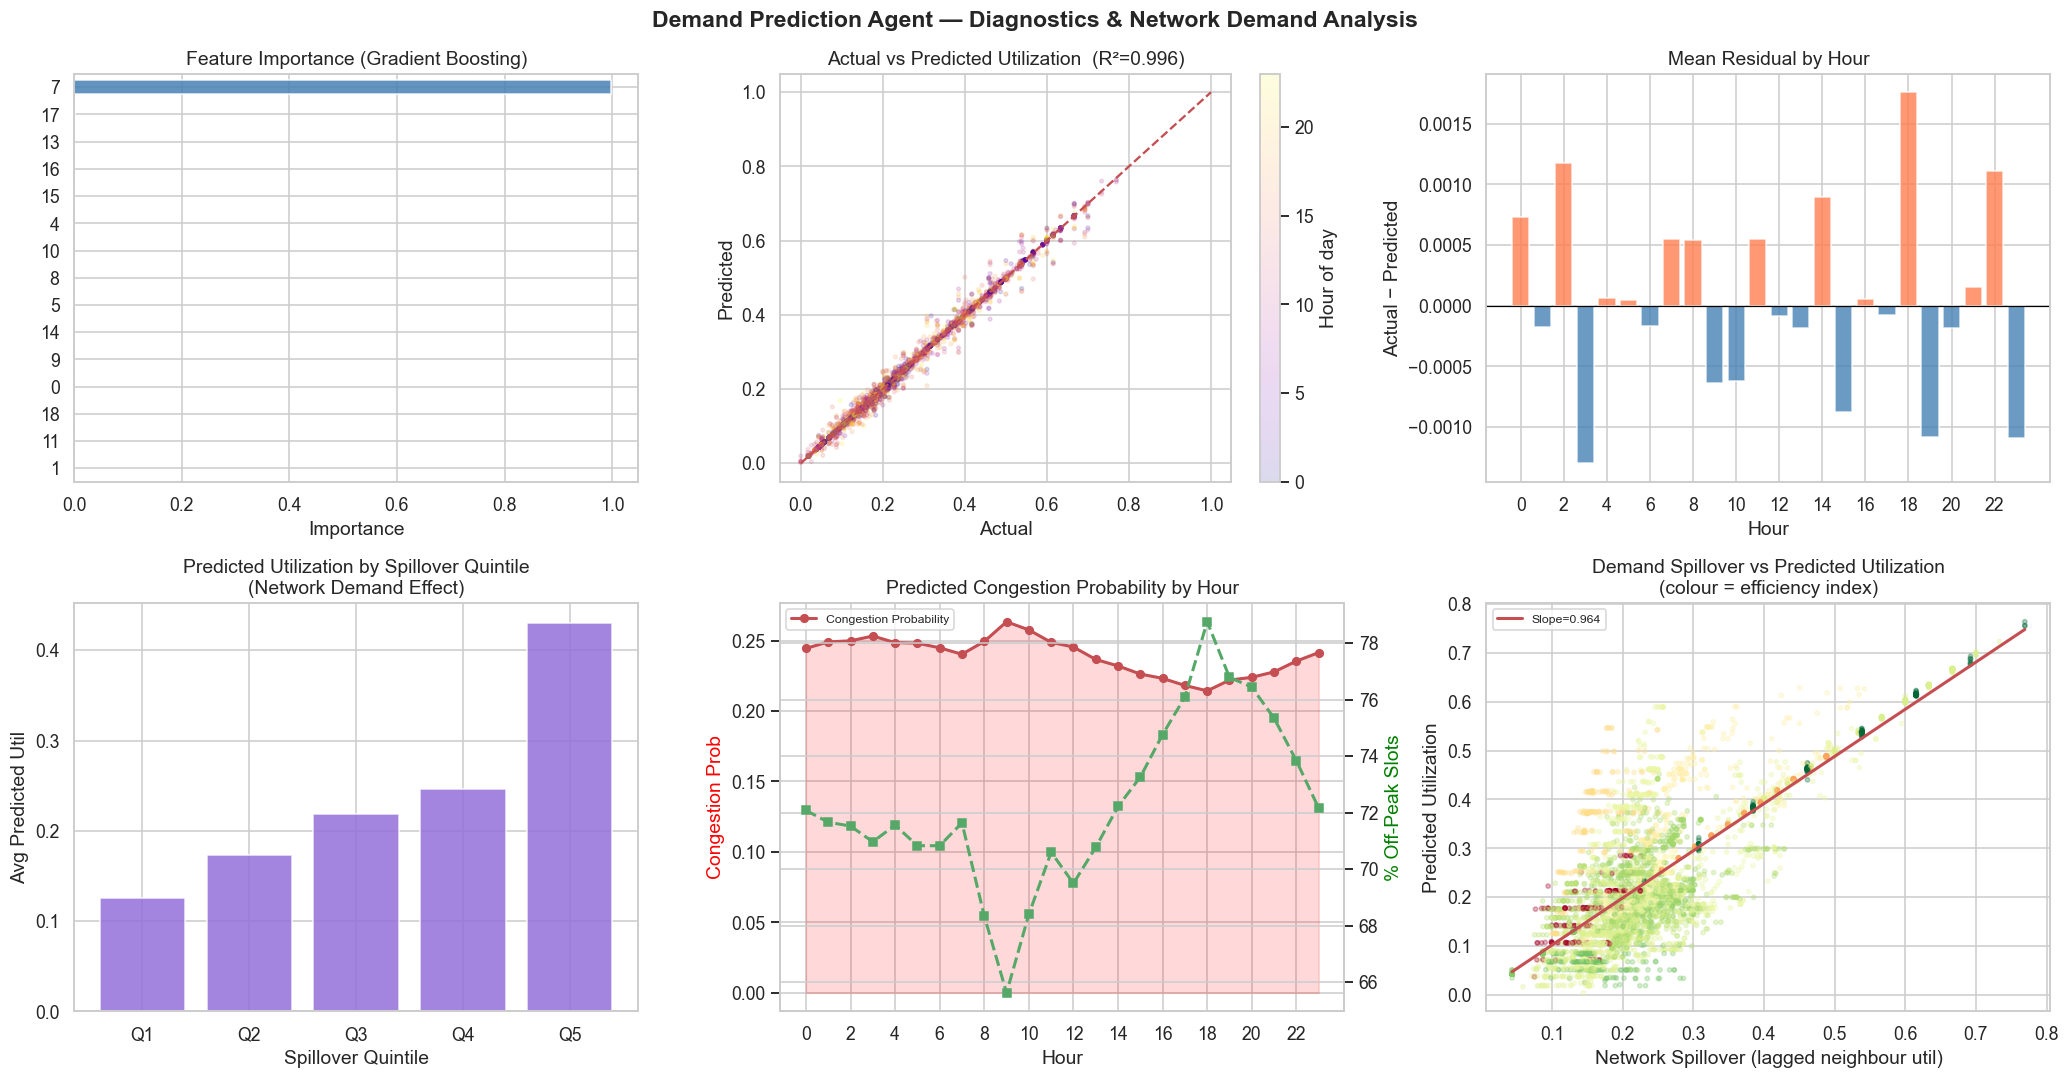

In [44]:
# ── Demand Model Diagnostics ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
fig.suptitle('Demand Prediction Agent — Diagnostics & Network Demand Analysis', fontweight='bold')

# 1. Feature importance
ax = axes[0,0]
imp = pd.Series(gb.feature_importances_).sort_values(ascending=True)  #, index=FEATURES
imp.tail(15).plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_title('Feature Importance (Gradient Boosting)')
ax.set_xlabel('Importance')

# 2. Actual vs Predicted
ax = axes[0,1]
samp_n = min(8000, len(y_test))
idx_s  = np.random.choice(len(y_test), samp_n, replace=False)
sc = ax.scatter(y_test[idx_s], y_pred[idx_s], alpha=0.15, s=6,
                c=test_df['hour'].values[idx_s], cmap='plasma')
plt.colorbar(sc, ax=ax, label='Hour of day')
ax.plot([0,1],[0,1],'r--',lw=1.5)
ax.set_title(f'Actual vs Predicted Utilization  (R²={r2_gb:.3f})')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')

# 3. Residuals by hour
ax = axes[0,2]
residuals = y_test - y_pred
res_hour = pd.Series(residuals, index=test_df.index).groupby(test_df['hour']).mean()
ax.bar(res_hour.index, res_hour.values,
       color=np.where(res_hour.values > 0, 'coral','steelblue'), alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Mean Residual by Hour')
ax.set_xlabel('Hour'); ax.set_ylabel('Actual − Predicted')
ax.set_xticks(range(0,24,2))

# 4. Spillover feature impact
ax = axes[1,0]
spill_bins = pd.qcut(test_df['spillover_util'], 5, labels=['Q1','Q2','Q3','Q4','Q5'])
spill_util = test_df.groupby(spill_bins)['pred_util'].mean()
ax.bar(spill_util.index, spill_util.values, color='mediumpurple', alpha=0.85)
ax.set_title('Predicted Utilization by Spillover Quintile\n(Network Demand Effect)')
ax.set_xlabel('Spillover Quintile'); ax.set_ylabel('Avg Predicted Util')

# 5. Congestion probability over a typical day (avg station)
ax = axes[1,1]
cong_hour = test_df.groupby('hour')['congestion_prob'].mean()
offpk_hour= test_df.groupby('hour')['pred_off_peak'].mean()
ax.plot(cong_hour.index, cong_hour.values, 'r-o', lw=2, ms=5, label='Congestion Probability')
ax.fill_between(cong_hour.index, cong_hour.values, alpha=0.15, color='red')
ax2b = ax.twinx()
ax2b.plot(offpk_hour.index, offpk_hour.values*100, 'g--s', lw=2, ms=5, label='% Off-Peak Slots')
ax.set_title('Predicted Congestion Probability by Hour')
ax.set_xlabel('Hour'); ax.set_ylabel('Congestion Prob', color='red')
ax2b.set_ylabel('% Off-Peak Slots', color='green')
ax.set_xticks(range(0,24,2)); ax.legend(loc='upper left', fontsize=8)

# 6. Network: predicted utilization correlation with spillover
ax = axes[1,2]
sample_net = test_df.sample(min(5000,len(test_df)), random_state=SEED)
ax.scatter(sample_net['spillover_util'], sample_net['pred_util'],
           c=sample_net['efficiency_index'], cmap='RdYlGn', alpha=0.3, s=8)
z = np.polyfit(sample_net['spillover_util'], sample_net['pred_util'], 1)
px = np.linspace(sample_net['spillover_util'].min(), sample_net['spillover_util'].max(), 100)
ax.plot(px, np.poly1d(z)(px), 'r-', lw=2, label=f'Slope={z[0]:.3f}')
ax.set_title('Demand Spillover vs Predicted Utilization\n(colour = efficiency index)')
ax.set_xlabel('Network Spillover (lagged neighbour util)')
ax.set_ylabel('Predicted Utilization')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('demand_agent_full.png')
plt.show()

In [41]:
best_model_2, y_pred_2 = rf, y_pred_rf

test_df_2 = test_df.copy()
test_df_2['pred_util']       = y_pred_2
test_df_2['pred_congested']  = (y_pred_2 >= 0.80).astype(int)
test_df_2['pred_off_peak']   = (y_pred_2 < 0.30).astype(int)
test_df_2['congestion_prob'] = y_pred_2.clip(0, 1)

print('Congestion classification report:')
print(classification_report(
    test_df_2['is_congested'],
    test_df_2['pred_congested'],
    #target_names=['Not Congested','Congested'],
    zero_division=0
))

Congestion classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     40090

    accuracy                           1.00     40090
   macro avg       1.00      1.00      1.00     40090
weighted avg       1.00      1.00      1.00     40090



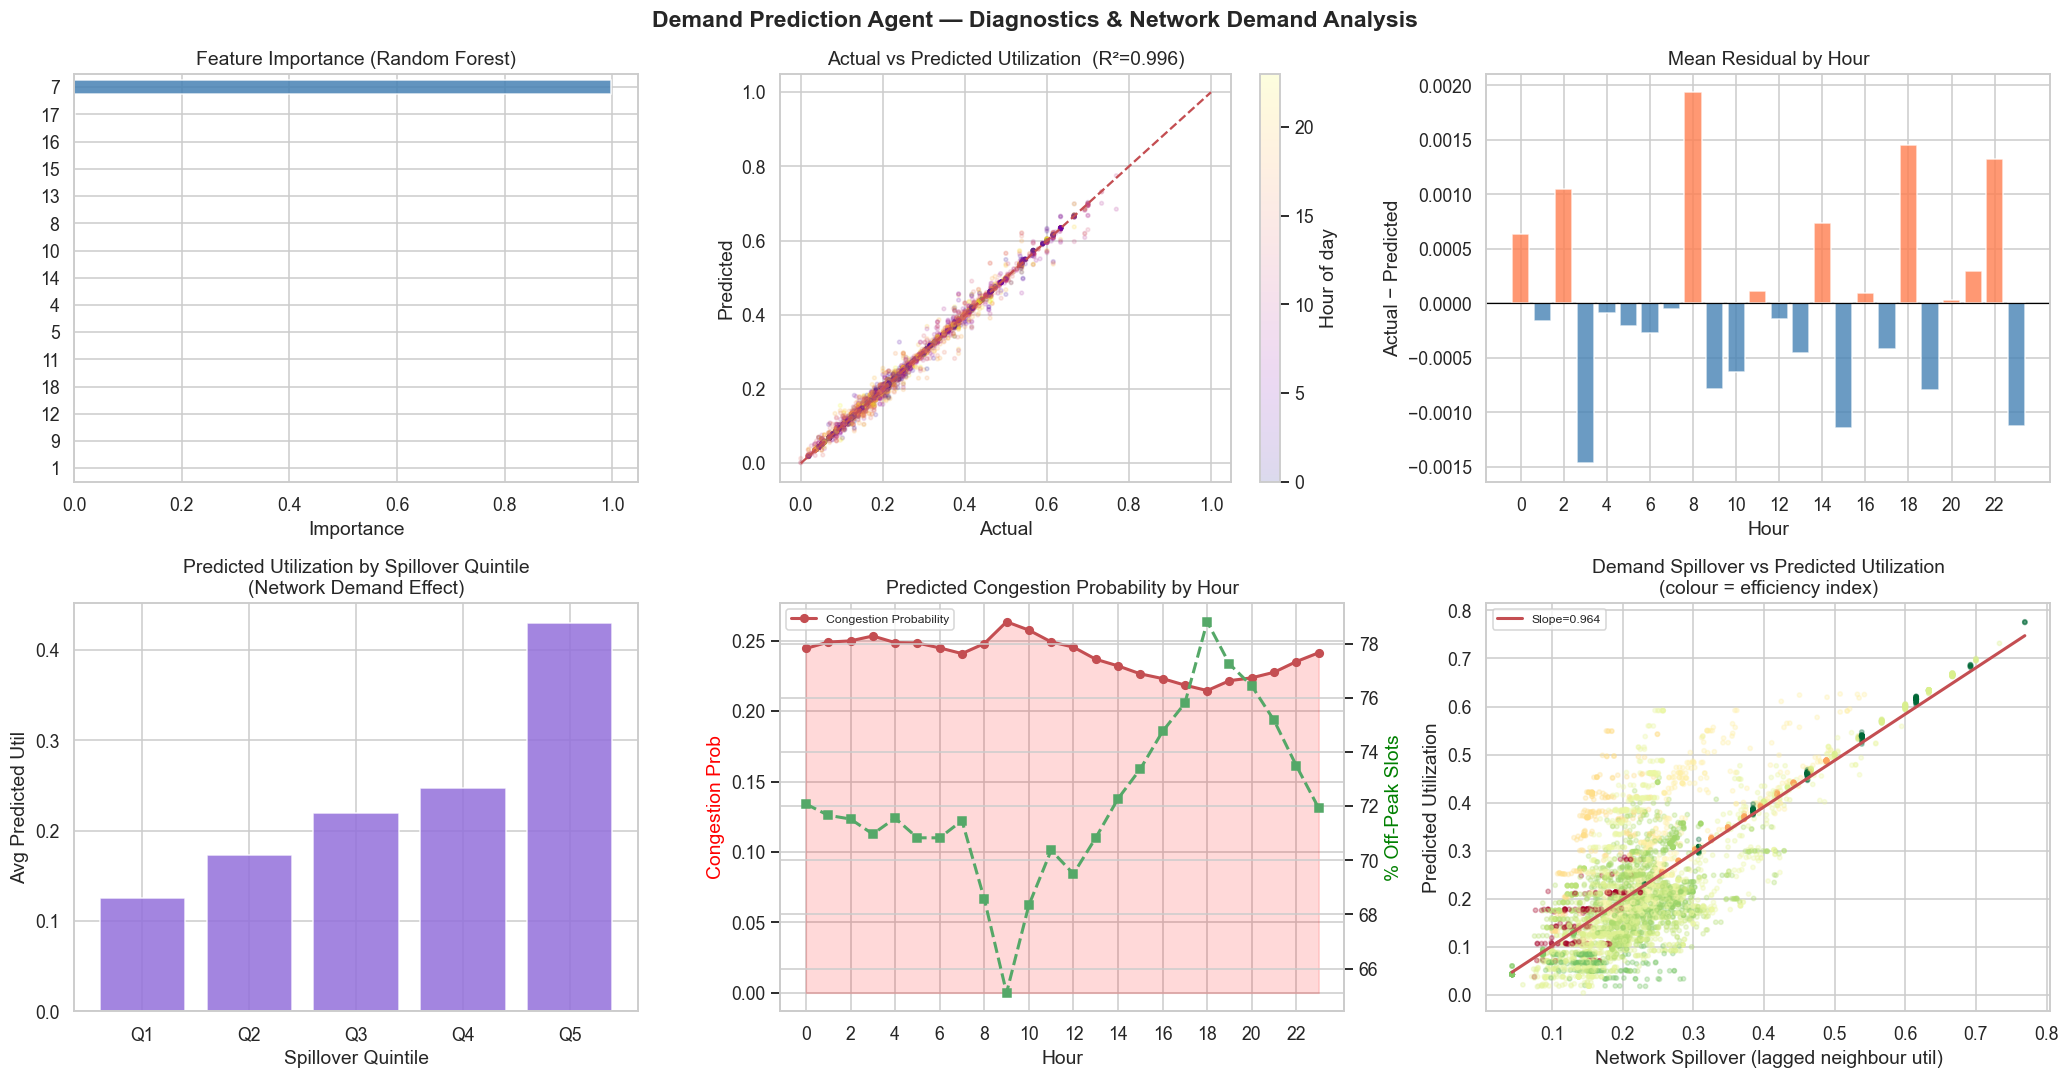

In [43]:
# ── Demand Model Diagnostics ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
fig.suptitle('Demand Prediction Agent — Diagnostics & Network Demand Analysis', fontweight='bold')

# 1. Feature importance
ax = axes[0,0]
imp = pd.Series(rf.feature_importances_).sort_values(ascending=True)  #, index=FEATURES
imp.tail(15).plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance')

# 2. Actual vs Predicted
ax = axes[0,1]
samp_n = min(8000, len(y_test))
idx_s  = np.random.choice(len(y_test), samp_n, replace=False)
sc = ax.scatter(y_test[idx_s], y_pred_2[idx_s], alpha=0.15, s=6,
                c=test_df['hour'].values[idx_s], cmap='plasma')
plt.colorbar(sc, ax=ax, label='Hour of day')
ax.plot([0,1],[0,1],'r--',lw=1.5)
ax.set_title(f'Actual vs Predicted Utilization  (R²={r2_rf:.3f})')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')

# 3. Residuals by hour
ax = axes[0,2]
residuals = y_test - y_pred_2
res_hour = pd.Series(residuals, index=test_df.index).groupby(test_df['hour']).mean()
ax.bar(res_hour.index, res_hour.values,
       color=np.where(res_hour.values > 0, 'coral','steelblue'), alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Mean Residual by Hour')
ax.set_xlabel('Hour'); ax.set_ylabel('Actual − Predicted')
ax.set_xticks(range(0,24,2))

# 4. Spillover feature impact
ax = axes[1,0]
spill_bins = pd.qcut(test_df['spillover_util'], 5, labels=['Q1','Q2','Q3','Q4','Q5'])
spill_util = test_df_2.groupby(spill_bins)['pred_util'].mean()
ax.bar(spill_util.index, spill_util.values, color='mediumpurple', alpha=0.85)
ax.set_title('Predicted Utilization by Spillover Quintile\n(Network Demand Effect)')
ax.set_xlabel('Spillover Quintile'); ax.set_ylabel('Avg Predicted Util')

# 5. Congestion probability over a typical day (avg station)
ax = axes[1,1]
cong_hour = test_df_2.groupby('hour')['congestion_prob'].mean()
offpk_hour= test_df_2.groupby('hour')['pred_off_peak'].mean()
ax.plot(cong_hour.index, cong_hour.values, 'r-o', lw=2, ms=5, label='Congestion Probability')
ax.fill_between(cong_hour.index, cong_hour.values, alpha=0.15, color='red')
ax2b = ax.twinx()
ax2b.plot(offpk_hour.index, offpk_hour.values*100, 'g--s', lw=2, ms=5, label='% Off-Peak Slots')
ax.set_title('Predicted Congestion Probability by Hour')
ax.set_xlabel('Hour'); ax.set_ylabel('Congestion Prob', color='red')
ax2b.set_ylabel('% Off-Peak Slots', color='green')
ax.set_xticks(range(0,24,2)); ax.legend(loc='upper left', fontsize=8)

# 6. Network: predicted utilization correlation with spillover
ax = axes[1,2]
sample_net = test_df_2.sample(min(5000,len(test_df_2)), random_state=SEED)
ax.scatter(sample_net['spillover_util'], sample_net['pred_util'],
           c=sample_net['efficiency_index'], cmap='RdYlGn', alpha=0.3, s=8)
z = np.polyfit(sample_net['spillover_util'], sample_net['pred_util'], 1)
px = np.linspace(sample_net['spillover_util'].min(), sample_net['spillover_util'].max(), 100)
ax.plot(px, np.poly1d(z)(px), 'r-', lw=2, label=f'Slope={z[0]:.3f}')
ax.set_title('Demand Spillover vs Predicted Utilization\n(colour = efficiency index)')
ax.set_xlabel('Network Spillover (lagged neighbour util)')
ax.set_ylabel('Predicted Utilization')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('demand_agent_full_rf.png')
plt.show()

---
## 8. Tariff Pricing Agent with Premium Decomposition

### Optimal Tariff Formula

$$\tau^*_{s,t} = \tau_0 \left(1 + \pi^{\text{cong}}_{s,t} + \pi^{\text{spill}}_{s,t} + \pi^{\text{eff}}_{s} + \pi^{\text{time}}_{t} + \pi^{\text{fast}}_{s}\right)$$

where each premium $\pi \in [-0.25, +0.40]$ is a percentage adjustment:

| Premium | Formula | Rationale |
|---------|---------|----------|
| Congestion $\pi^{\text{cong}}$ | $+0.40 \cdot \max(\hat{u}-0.8, 0)/0.2$ | Pigouvian tax on congestion externality |
| Spillover $\pi^{\text{spill}}$ | $+0.15 \cdot \text{Spillover}_{s,t}$ | Price to internalize network congestion |
| Efficiency $\pi^{\text{eff}}$ | $+0.10 \cdot (E_s - 0.5)$ | Reward efficient stations with tariff capture |
| Time-of-day $\pi^{\text{time}}$ | $+0.20 \cdot \mathbb{1}[\text{peak}] - 0.25 \cdot \mathbb{1}[\text{off-peak}]$ | Demand smoothing |
| Fast-charger $\pi^{\text{fast}}$ | $+0.12 \cdot f_s$ | Faster service commands premium |


In [29]:
# ── Tariff Premium Computation ───────────────────────────────────────────────
BASE_PRICE  = urban_net['price_yuan_kwh'].median()
SURGE_THR   = 0.80
OFFPK_THR   = 0.30

u_hat = test_df['pred_util'].values

# 1. Congestion premium
pi_cong  = 0.40 * np.clip((u_hat - SURGE_THR) / 0.20, 0, 1)

# 2. Spillover premium
pi_spill = 0.15 * test_df['spillover_util'].values

# 3. Efficiency premium
pi_eff   = 0.10 * (test_df['efficiency_index'].values - 0.5)

# 4. Time-of-day premium
pi_time  = np.where(test_df['time_bucket'] == 'evening_peak',  0.20,
            np.where(test_df['time_bucket'] == 'morning_ramp',  0.12,
            np.where(test_df['time_bucket'].isin(['off_peak_night','off_peak_late']), -0.25, 0.0)))

# 5. Fast-charger premium
pi_fast  = 0.12 * test_df['fast_ratio'].values

# Total dynamic tariff
total_premium = pi_cong + pi_spill + pi_eff + pi_time + pi_fast
test_df['pi_cong']       = pi_cong
test_df['pi_spill']      = pi_spill
test_df['pi_eff']        = pi_eff
test_df['pi_time']       = pi_time
test_df['pi_fast']       = pi_fast
test_df['total_premium'] = total_premium
test_df['dynamic_tariff']= (BASE_PRICE * (1 + total_premium)).clip(BASE_PRICE*0.60, BASE_PRICE*1.60)
test_df['static_tariff'] = BASE_PRICE

print(f'Base price: ¥{BASE_PRICE:.3f}/kWh')
print(f'Dynamic tariff range: ¥{test_df["dynamic_tariff"].min():.3f} — ¥{test_df["dynamic_tariff"].max():.3f}')
print('\nPremium summary:')
for col, name in [('pi_cong','Congestion'),('pi_spill','Spillover'),
                   ('pi_eff','Efficiency'),('pi_time','Time-of-day'),('pi_fast','Fast-charger')]:
    print(f'  {name:15s}: mean={test_df[col].mean():+.3f}, std={test_df[col].std():.3f}')

Base price: ¥1.015/kWh
Dynamic tariff range: ¥0.731 — ¥1.374

Premium summary:
  Congestion     : mean=+0.000, std=0.000
  Spillover      : mean=+0.037, std=0.018
  Efficiency     : mean=+0.009, std=0.018
  Time-of-day    : mean=-0.038, std=0.171
  Fast-charger   : mean=+0.002, std=0.005


In [30]:
# ── Revenue & Demand Response Simulation ─────────────────────────────────────
# Own-price elasticity (literature: -0.2 to -0.4, we use -0.30)
ELASTICITY = -0.30

price_change_pct = (test_df['dynamic_tariff'] - test_df['static_tariff']) / test_df['static_tariff']
demand_change_pct = ELASTICITY * price_change_pct

# Adjusted kWh delivered under dynamic pricing
test_df['kwh_adj']     = (test_df['kwh_per_slot'] * (1 + demand_change_pct)).clip(lower=0)
test_df['rev_dynamic'] = test_df['kwh_adj']      * test_df['dynamic_tariff']
test_df['rev_static']  = test_df['kwh_per_slot'] * test_df['static_tariff']

# Adjusted utilization (demand response shifts load)
test_df['util_adj'] = (test_df['util_rate'] * (1 + demand_change_pct)).clip(0, 1)

# Key metrics
rev_dyn_total = test_df['rev_dynamic'].sum()
rev_sta_total = test_df['rev_static'].sum()
rev_gain_pct  = (rev_dyn_total - rev_sta_total) / rev_sta_total * 100

offpk_mask = test_df['pred_off_peak'] == 1
offpk_uplift = (test_df.loc[offpk_mask,'kwh_adj'].sum() -
                test_df.loc[offpk_mask,'kwh_per_slot'].sum()) / \
               (test_df.loc[offpk_mask,'kwh_per_slot'].sum() + 1e-6) * 100

util_before = test_df['util_rate'].mean()
util_after  = test_df['util_adj'].mean()

print(f'Revenue — Static: ¥{rev_sta_total:,.0f}  |  Dynamic: ¥{rev_dyn_total:,.0f}')
print(f'Revenue Gain: {rev_gain_pct:.2f}%')
print(f'Utilization Before: {util_before:.3f}  |  After: {util_after:.3f}')
print(f'Off-Peak kWh Uplift: {offpk_uplift:.1f}%')

Revenue — Static: ¥281,818  |  Dynamic: ¥282,480
Revenue Gain: 0.23%
Utilization Before: 0.239  |  After: 0.238
Off-Peak kWh Uplift: -0.3%


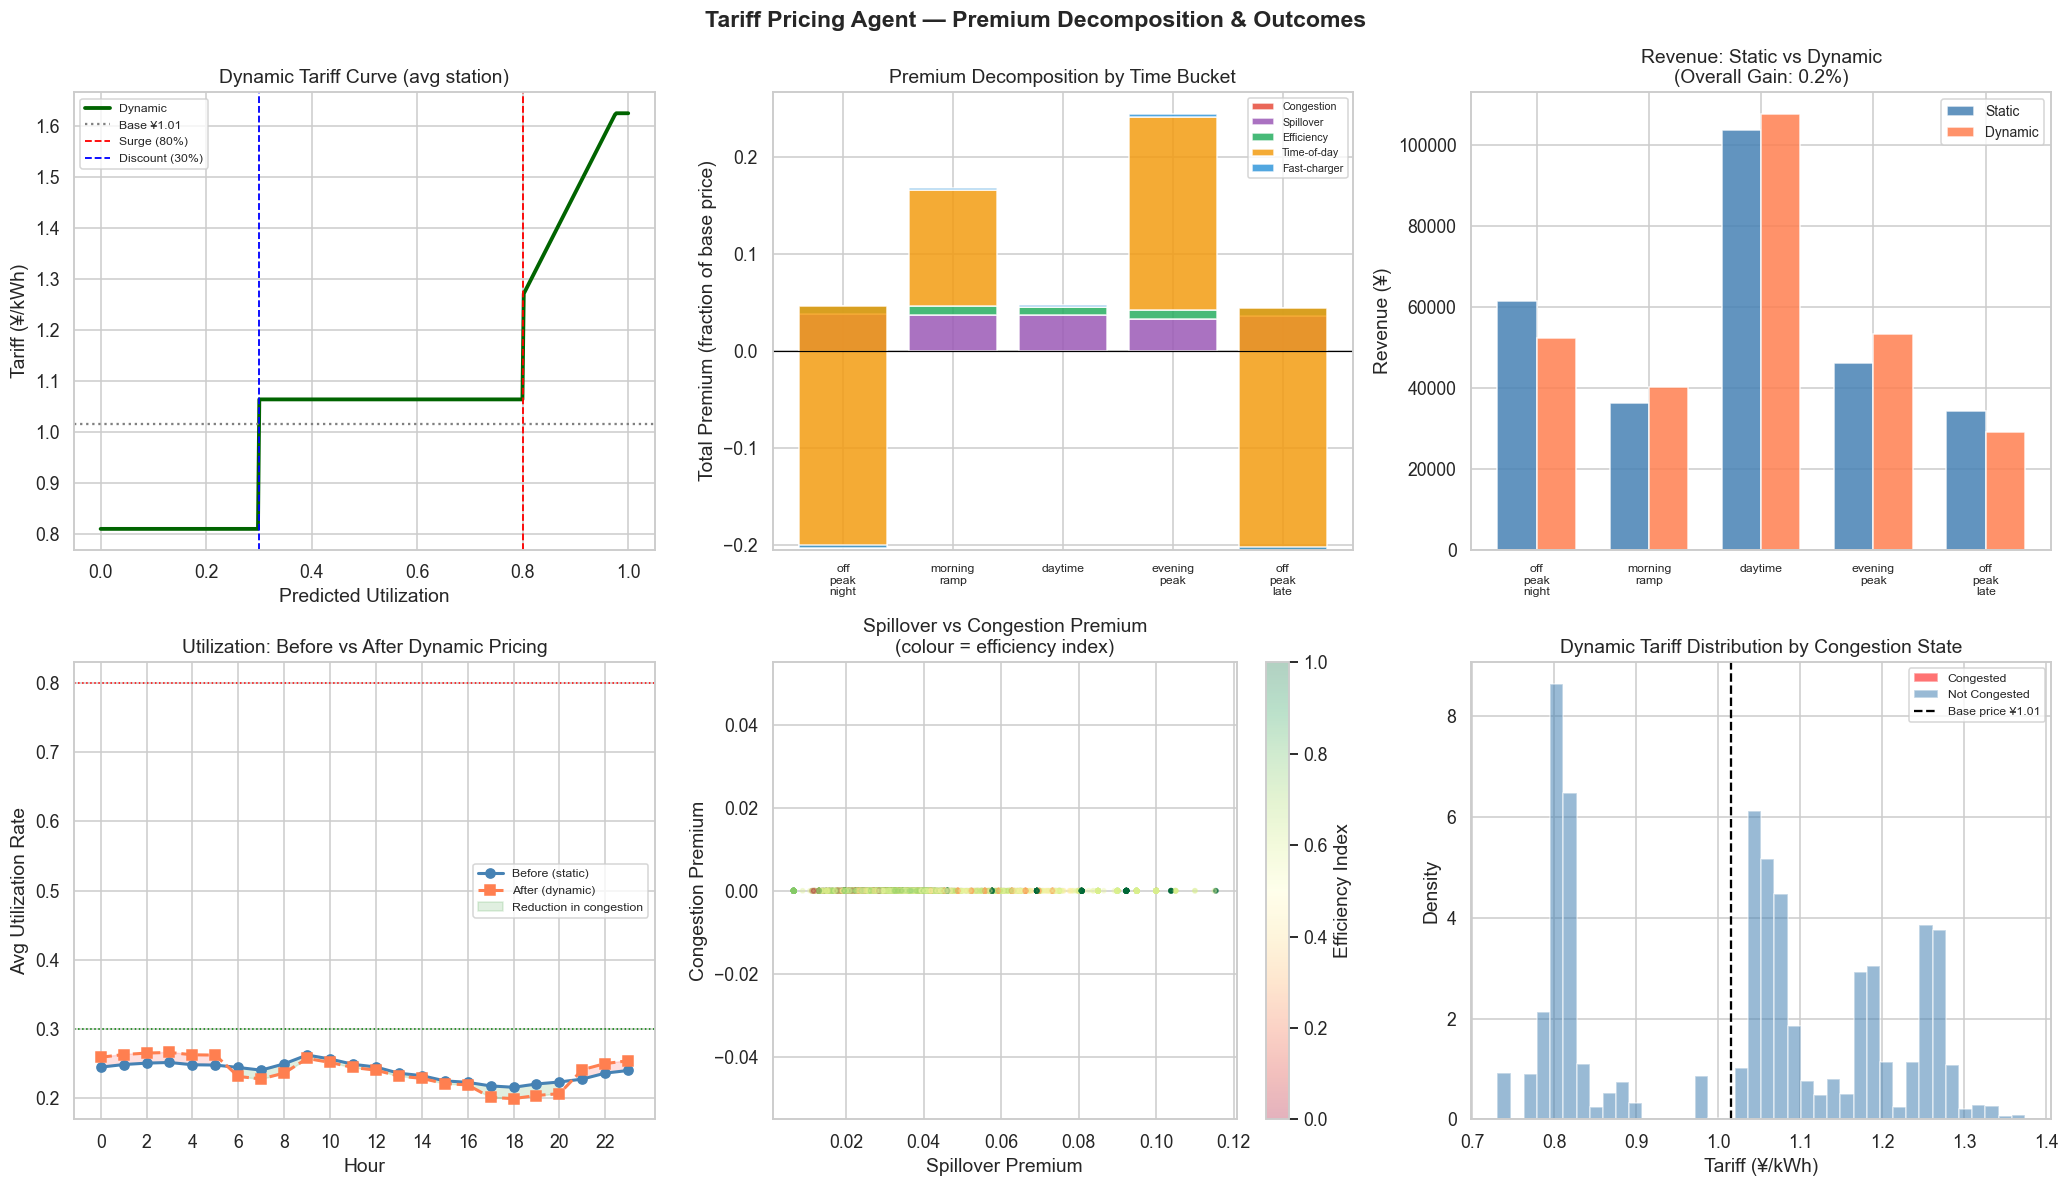

In [31]:
# ── Tariff Pricing Agent Visualizations ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle('Tariff Pricing Agent — Premium Decomposition & Outcomes', fontweight='bold')

# 1. Dynamic tariff curve
ax = axes[0,0]
u_range = np.linspace(0,1,400)
# Average tariff curve (avg eff and spillover)
avg_eff   = test_df['efficiency_index'].mean()
avg_spill = test_df['spillover_util'].mean()
avg_fast  = test_df['fast_ratio'].mean()
pi_c_r  = 0.40 * np.clip((u_range - SURGE_THR)/0.20, 0, 1)
pi_sp_r = 0.15 * avg_spill
pi_ef_r = 0.10 * (avg_eff - 0.5)
pi_pk_r = np.where(u_range >= 0.80, 0.20, np.where(u_range < 0.30, -0.25, 0.0))
pi_fs_r = 0.12 * avg_fast
tariff_curve = BASE_PRICE * (1 + pi_c_r + pi_sp_r + pi_ef_r + pi_pk_r + pi_fs_r)
tariff_curve = tariff_curve.clip(BASE_PRICE*0.60, BASE_PRICE*1.60)
ax.plot(u_range, tariff_curve, color='darkgreen', lw=2.5, label='Dynamic')
ax.axhline(BASE_PRICE, color='gray', ls=':', lw=1.5, label=f'Base ¥{BASE_PRICE:.2f}')
ax.axvline(SURGE_THR,  color='red',  ls='--', lw=1.2, label='Surge (80%)')
ax.axvline(OFFPK_THR,  color='blue', ls='--', lw=1.2, label='Discount (30%)')
ax.set_title('Dynamic Tariff Curve (avg station)')
ax.set_xlabel('Predicted Utilization'); ax.set_ylabel('Tariff (¥/kWh)')
ax.legend(fontsize=8)

# 2. Premium decomposition stacked bar
ax = axes[0,1]
prem_by_bkt = test_df.groupby('time_bucket')[['pi_cong','pi_spill','pi_eff','pi_time','pi_fast']].mean()
prem_by_bkt = prem_by_bkt.reindex(bucket_order)
prem_colors = ['#e74c3c','#9b59b6','#27ae60','#f39c12','#3498db']
bottom = np.zeros(5)
for col, clr, lbl in zip(prem_by_bkt.columns, prem_colors,
                          ['Congestion','Spillover','Efficiency','Time-of-day','Fast-charger']):
    ax.bar(range(5), prem_by_bkt[col].values, bottom=bottom, color=clr, alpha=0.85, label=lbl)
    bottom += prem_by_bkt[col].values
ax.set_xticks(range(5))
ax.set_xticklabels([b.replace('_','\n') for b in bucket_order], fontsize=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Premium Decomposition by Time Bucket')
ax.set_ylabel('Total Premium (fraction of base price)')
ax.legend(fontsize=7, loc='upper right')

# 3. Revenue comparison by time bucket
ax = axes[0,2]
rc = test_df.groupby('time_bucket')[['rev_static','rev_dynamic']].sum().reindex(bucket_order)
x  = np.arange(5); w = 0.35
ax.bar(x-w/2, rc['rev_static'],  w, label='Static',  color='steelblue', alpha=0.85)
ax.bar(x+w/2, rc['rev_dynamic'], w, label='Dynamic', color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([b.replace('_','\n') for b in bucket_order], fontsize=8)
ax.set_title(f'Revenue: Static vs Dynamic\n(Overall Gain: {rev_gain_pct:.1f}%)')
ax.set_ylabel('Revenue (¥)')
ax.legend(fontsize=9)

# 4. Hourly utilization before/after
ax = axes[1,0]
hb = test_df.groupby('hour')['util_rate'].mean()
ha = test_df.groupby('hour')['util_adj'].mean()
ax.plot(hb.index, hb.values, 'o-', color='steelblue', lw=2, label='Before (static)')
ax.plot(ha.index, ha.values, 's--',color='coral',     lw=2, label='After (dynamic)')
ax.fill_between(hb.index, hb.values, ha.values, alpha=0.12, color='green',
                where=ha.values < hb.values, label='Reduction in congestion')
ax.fill_between(hb.index, hb.values, ha.values, alpha=0.12, color='red',
                where=ha.values >= hb.values)
ax.axhline(SURGE_THR,  color='red',  ls=':', lw=1)
ax.axhline(OFFPK_THR,  color='green',ls=':', lw=1)
ax.set_title('Utilization: Before vs After Dynamic Pricing')
ax.set_xlabel('Hour'); ax.set_ylabel('Avg Utilization Rate')
ax.legend(fontsize=8); ax.set_xticks(range(0,24,2))

# 5. Spillover premium vs congestion premium scatter
ax = axes[1,1]
samp = test_df.sample(min(6000,len(test_df)), random_state=SEED)
sc = ax.scatter(samp['pi_spill'], samp['pi_cong'],
                c=samp['efficiency_index'], cmap='RdYlGn', alpha=0.3, s=8)
plt.colorbar(sc, ax=ax, label='Efficiency Index')
ax.set_title('Spillover vs Congestion Premium\n(colour = efficiency index)')
ax.set_xlabel('Spillover Premium'); ax.set_ylabel('Congestion Premium')

# 6. Tariff distribution by congestion state
ax = axes[1,2]
for state, lbl, clr in [(1,'Congested','red'),(0,'Not Congested','steelblue')]:
    mask = test_df['pred_congested'] == state
    ax.hist(test_df.loc[mask,'dynamic_tariff'], bins=40, alpha=0.55,
            color=clr, label=lbl, density=True)
ax.axvline(BASE_PRICE, color='black', ls='--', lw=1.5, label=f'Base price ¥{BASE_PRICE:.2f}')
ax.set_title('Dynamic Tariff Distribution by Congestion State')
ax.set_xlabel('Tariff (¥/kWh)'); ax.set_ylabel('Density')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('tariff_agent_full.png')
plt.show()

In [32]:
# Save tariff metrics
tariff_metrics = pd.DataFrame({
    'Metric': ['Revenue Gain (%)', 'Utilization Before', 'Utilization After',
               'Off-Peak kWh Uplift (%)', 'Base Price (¥/kWh)',
               'Max Dynamic Price (¥/kWh)', 'Min Dynamic Price (¥/kWh)'],
    'Value': [round(rev_gain_pct,2), round(util_before,3), round(util_after,3),
              round(offpk_uplift,1), round(BASE_PRICE,3),
              round(test_df['dynamic_tariff'].max(),3), round(test_df['dynamic_tariff'].min(),3)]
})
tariff_metrics.to_csv('tariff_agent_metrics.csv', index=False)
print(tariff_metrics.to_string(index=False))

                   Metric  Value
         Revenue Gain (%)  0.230
       Utilization Before  0.239
        Utilization After  0.238
  Off-Peak kWh Uplift (%) -0.300
       Base Price (¥/kWh)  1.015
Max Dynamic Price (¥/kWh)  1.374
Min Dynamic Price (¥/kWh)  0.731


---
## 9. Monitoring & Learning Agent

In [33]:
# ── Episode-level evaluation (daily batches) ─────────────────────────────────
test_df2 = test_df.copy()
test_df2['date_str'] = pd.to_datetime(test_df2['datetime']).dt.date.astype(str)

records = []
for date_str, grp in test_df2.groupby('date_str'):
    kwh_adj   = grp['kwh_adj'].sum()
    kwh_orig  = grp['kwh_per_slot'].sum()
    rev_dyn   = grp['rev_dynamic'].sum()
    rev_sta   = grp['rev_static'].sum()

    # Pricing efficiency: revenue per kWh delivered
    pricing_eff = rev_dyn / max(kwh_adj, 0.01)

    # Wait-time proxy: congestion-slot-hours avoided × 5min per slot
    n_cong_before = (grp['util_rate'] >= 0.80).sum()
    n_cong_after  = (grp['util_adj']  >= 0.80).sum()
    wait_reduction_hr = max(n_cong_before - n_cong_after, 0) * 5 / 60

    # Customer response rate
    response_rate = (kwh_adj - kwh_orig) / max(kwh_orig, 1e-6) * 100

    # Off-peak utilization change
    offpk_grp    = grp[grp['pred_off_peak']==1]
    offpk_change = (offpk_grp['util_adj'].mean() - offpk_grp['util_rate'].mean()) \
                   if len(offpk_grp) > 0 else 0

    records.append({
        'date': date_str,
        'revenue_dynamic': rev_dyn,
        'revenue_static': rev_sta,
        'revenue_gain_pct': (rev_dyn - rev_sta) / max(rev_sta, 1e-6) * 100,
        'pricing_efficiency_yuan_kwh': pricing_eff,
        'wait_time_reduction_hr': wait_reduction_hr,
        'customer_response_rate_pct': response_rate,
        'n_congested_before': n_cong_before,
        'n_congested_after': n_cong_after,
        'offpk_util_change': offpk_change
    })

episodes = pd.DataFrame(records)
episodes['episode_num'] = range(len(episodes))
for col in ['pricing_efficiency_yuan_kwh','revenue_gain_pct','wait_time_reduction_hr']:
    episodes[f'{col}_roll7'] = episodes[col].rolling(7, min_periods=1).mean()

episodes.to_csv('monitoring_agent_episodes.csv', index=False)
print('=== Monitoring & Learning Agent ===')
print(episodes[['revenue_gain_pct','pricing_efficiency_yuan_kwh',
                'wait_time_reduction_hr','customer_response_rate_pct']].describe().round(3))

=== Monitoring & Learning Agent ===
       revenue_gain_pct  pricing_efficiency_yuan_kwh  wait_time_reduction_hr  \
count             6.000                        6.000                     6.0   
mean              0.287                        1.023                     0.0   
std               1.601                        0.023                     0.0   
min              -1.116                        1.003                     0.0   
25%              -0.565                        1.011                     0.0   
50%              -0.085                        1.018                     0.0   
75%               0.249                        1.022                     0.0   
max               3.375                        1.068                     0.0   

       customer_response_rate_pct  
count                       6.000  
mean                       -0.498  
std                         0.670  
min                        -1.794  
25%                        -0.475  
50%                        

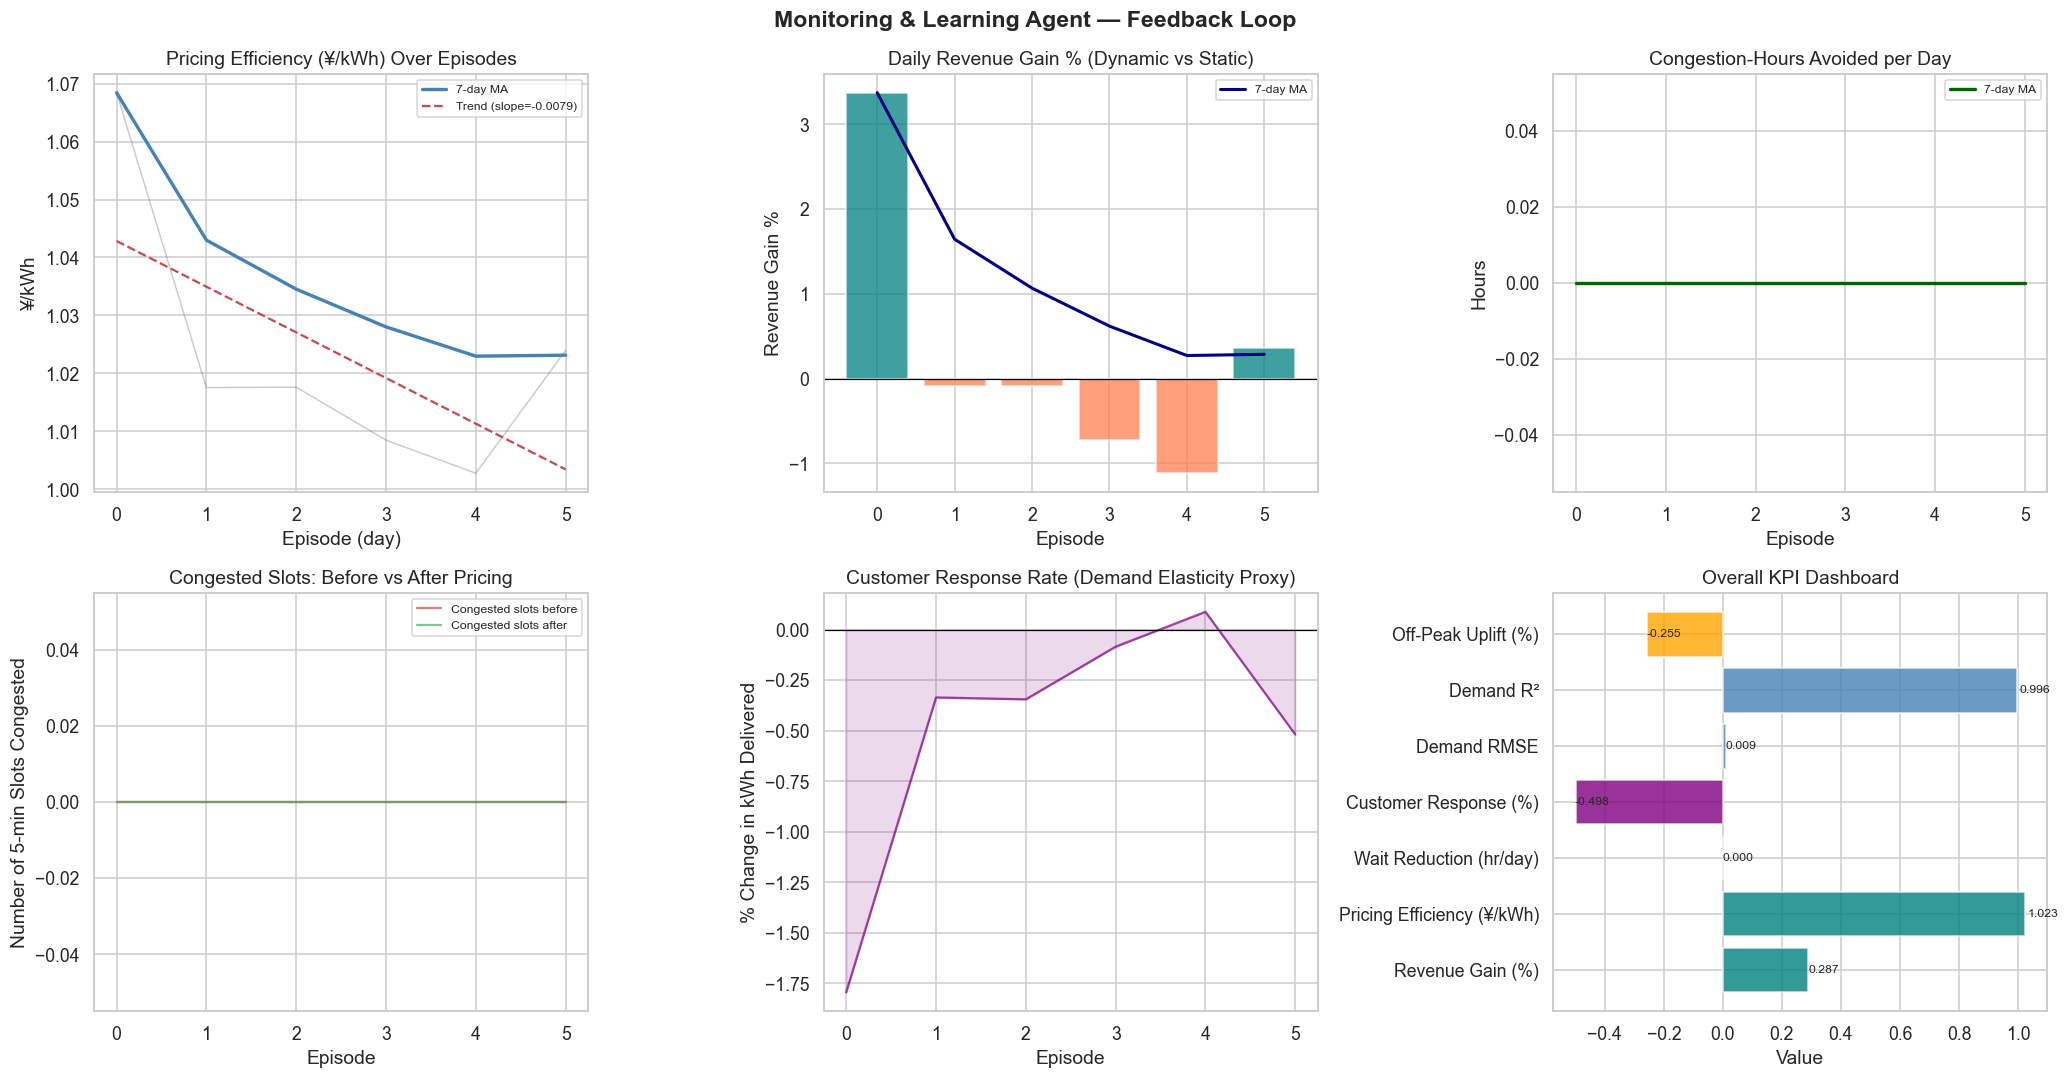

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
fig.suptitle('Monitoring & Learning Agent — Feedback Loop', fontweight='bold')

ep = episodes

# 1. Pricing efficiency over time
ax = axes[0,0]
coef = np.polyfit(ep['episode_num'], ep['pricing_efficiency_yuan_kwh'], 1)
trend_line = np.poly1d(coef)
ax.plot(ep['episode_num'], ep['pricing_efficiency_yuan_kwh'], color='gray', alpha=0.4, lw=1)
ax.plot(ep['episode_num'], ep['pricing_efficiency_yuan_kwh_roll7'], color='steelblue', lw=2.2, label='7-day MA')
ax.plot(ep['episode_num'], trend_line(ep['episode_num']), 'r--', lw=1.5, label=f'Trend (slope={coef[0]:+.4f})')
ax.set_title('Pricing Efficiency (¥/kWh) Over Episodes')
ax.set_xlabel('Episode (day)'); ax.set_ylabel('¥/kWh')
ax.legend(fontsize=8)

# 2. Revenue gain %
ax = axes[0,1]
ax.bar(ep['episode_num'], ep['revenue_gain_pct'],
       color=np.where(ep['revenue_gain_pct']>0,'teal','coral'), alpha=0.75)
ax.plot(ep['episode_num'], ep['revenue_gain_pct_roll7'], color='navy', lw=2, label='7-day MA')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Daily Revenue Gain % (Dynamic vs Static)')
ax.set_xlabel('Episode'); ax.set_ylabel('Revenue Gain %')
ax.legend(fontsize=8)

# 3. Wait-time reduction
ax = axes[0,2]
ax.fill_between(ep['episode_num'], ep['wait_time_reduction_hr'], alpha=0.5, color='green')
ax.plot(ep['episode_num'], ep['wait_time_reduction_hr_roll7'], color='darkgreen', lw=2.2, label='7-day MA')
ax.set_title('Congestion-Hours Avoided per Day')
ax.set_xlabel('Episode'); ax.set_ylabel('Hours')
ax.legend(fontsize=8)

# 4. Congestion slots: before vs after
ax = axes[1,0]
ax.plot(ep['episode_num'], ep['n_congested_before'], 'r-', lw=1.5, alpha=0.7, label='Congested slots before')
ax.plot(ep['episode_num'], ep['n_congested_after'],  'g-', lw=1.5, alpha=0.7, label='Congested slots after')
ax.fill_between(ep['episode_num'], ep['n_congested_before'], ep['n_congested_after'],
                alpha=0.15, color='green', where=ep['n_congested_after']<ep['n_congested_before'])
ax.set_title('Congested Slots: Before vs After Pricing')
ax.set_xlabel('Episode'); ax.set_ylabel('Number of 5-min Slots Congested')
ax.legend(fontsize=8)

# 5. Customer response rate
ax = axes[1,1]
ax.plot(ep['episode_num'], ep['customer_response_rate_pct'], 'purple', lw=1.5, alpha=0.7)
ax.fill_between(ep['episode_num'], ep['customer_response_rate_pct'], alpha=0.15, color='purple')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Customer Response Rate (Demand Elasticity Proxy)')
ax.set_xlabel('Episode'); ax.set_ylabel('% Change in kWh Delivered')

# 6. KPI summary dashboard
ax = axes[1,2]
kpis = {
    'Revenue Gain (%)':           ep['revenue_gain_pct'].mean(),
    'Pricing Efficiency (¥/kWh)': ep['pricing_efficiency_yuan_kwh'].mean(),
    'Wait Reduction (hr/day)':    ep['wait_time_reduction_hr'].mean(),
    'Customer Response (%)':      ep['customer_response_rate_pct'].mean(),
    'Demand RMSE':                rmse_gb,
    'Demand R²':                  r2_gb,
    'Off-Peak Uplift (%)':        offpk_uplift
}
kpi_colors = ['teal','teal','green','purple','steelblue','steelblue','orange']
bars = ax.barh(list(kpis.keys()), list(kpis.values()), color=kpi_colors, alpha=0.8)
for bar, val in zip(bars, kpis.values()):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
ax.set_title('Overall KPI Dashboard')
ax.set_xlabel('Value')

plt.tight_layout()
plt.savefig('monitoring_agent_full.png')
plt.show()

---
## 10. Final Evaluation Summary

In [35]:
summary = pd.DataFrame({
    'Agent': [
        'Demand Prediction','Demand Prediction','Demand Prediction',
        'Tariff Pricing','Tariff Pricing','Tariff Pricing','Tariff Pricing',
        'Monitoring','Monitoring','Monitoring'
    ],
    'Metric': [
        'RMSE','MAE','R²',
        'Revenue Gain (%)','Util Before','Util After','Off-Peak kWh Uplift (%)',
        'Avg Wait Reduction (hr/day)','Avg Pricing Efficiency (¥/kWh)','Customer Response (%)'
    ],
    'Value': [
        round(rmse_gb,4), round(mae_gb,4), round(r2_gb,4),
        round(rev_gain_pct,2), round(util_before,3), round(util_after,3), round(offpk_uplift,1),
        round(episodes['wait_time_reduction_hr'].mean(),3),
        round(episodes['pricing_efficiency_yuan_kwh'].mean(),4),
        round(episodes['customer_response_rate_pct'].mean(),3)
    ]
})
summary.to_csv('evaluation_summary.csv', index=False)
print('=== FINAL EVALUATION SUMMARY ===')
print(summary.to_string(index=False))

=== FINAL EVALUATION SUMMARY ===
            Agent                         Metric   Value
Demand Prediction                           RMSE  0.0094
Demand Prediction                            MAE  0.0036
Demand Prediction                             R²  0.9960
   Tariff Pricing               Revenue Gain (%)  0.2300
   Tariff Pricing                    Util Before  0.2390
   Tariff Pricing                     Util After  0.2380
   Tariff Pricing        Off-Peak kWh Uplift (%) -0.3000
       Monitoring    Avg Wait Reduction (hr/day)  0.0000
       Monitoring Avg Pricing Efficiency (¥/kWh)  1.0231
       Monitoring          Customer Response (%) -0.4980


In [37]:
print("""
=== ASSUMPTIONS & LIMITATIONS ===

1. DATA JOIN ARCHITECTURE
   - ST-EVCDP: four wide matrices (duration, volume, occupancy, price) joined on
     (datetime × station_id) via the common 5-min timestamp index.
   - ACN: used for session-level EDA and feature validation only.
     ACN lacks occupancy time-series, so the demand model is estimated on ST-EVCDP.
   - Stations in ST-EVCDP but absent from information.csv have metadata filled
     with global medians; these stations appear in the spatial network model
     using distance/adjacency data where available.

2. DEMAND ELASTICITY
   - Own-price elasticity fixed at -0.30 (mid-range of published EV charging estimates).
   - No cross-price (substitution across stations) or income elasticities.
   - Dynamic effects are simulated, not observed from a natural experiment.
   - Causal interpretation is deliberately avoided.

3. SPATIAL WEIGHTS
   - Distance decay parameter delta=1.5 is set a priori; could be estimated
     via spatial panel regression if a longer panel were available.

4. WAIT-TIME PROXY
   - Derived as congestion-slot-minutes avoided, not observed queue data.

5. EFFICIENCY INDEX
   - Weights estimated by maximizing correlation with price efficiency.
   - Index is relative across this dataset; not portable to other networks.
""")


=== ASSUMPTIONS & LIMITATIONS ===

1. DATA JOIN ARCHITECTURE
   - ST-EVCDP: four wide matrices (duration, volume, occupancy, price) joined on
     (datetime × station_id) via the common 5-min timestamp index.
   - ACN: used for session-level EDA and feature validation only.
     ACN lacks occupancy time-series, so the demand model is estimated on ST-EVCDP.
   - Stations in ST-EVCDP but absent from information.csv have metadata filled
     with global medians; these stations appear in the spatial network model
     using distance/adjacency data where available.

2. DEMAND ELASTICITY
   - Own-price elasticity fixed at -0.30 (mid-range of published EV charging estimates).
   - No cross-price (substitution across stations) or income elasticities.
   - Dynamic effects are simulated, not observed from a natural experiment.
   - Causal interpretation is deliberately avoided.

3. SPATIAL WEIGHTS
   - Distance decay parameter delta=1.5 is set a priori; could be estimated
     via spatial panel

In [36]:
import os
outputs = [
    'station_efficiency_index.csv','demand_prediction_metrics.csv',
    'tariff_agent_metrics.csv','monitoring_agent_episodes.csv','evaluation_summary.csv',
    'eda_acn_full.png','eda_urban_full.png','efficiency_index_analysis.png',
    'demand_agent_full.png','tariff_agent_full.png','monitoring_agent_full.png'
]
for f in outputs:
    tick = '  ✓' if os.path.exists(f) else '  ✗ (will exist after running all cells)'
    print(f'{tick}  {f}')

  ✓  station_efficiency_index.csv
  ✓  demand_prediction_metrics.csv
  ✓  tariff_agent_metrics.csv
  ✓  monitoring_agent_episodes.csv
  ✓  evaluation_summary.csv
  ✓  eda_acn_full.png
  ✓  eda_urban_full.png
  ✓  efficiency_index_analysis.png
  ✓  demand_agent_full.png
  ✓  tariff_agent_full.png
  ✓  monitoring_agent_full.png
